# **CortiSoul** **-** **Data** **Science**

## 🧩 **Problem Definition & Business Understanding**

Dalam lingkungan akademik dan profesional, banyak individu mengalami tekanan yang tinggi tanpa memiliki kesadaran yang cukup terhadap kondisi emosional dan tingkat stres yang mereka alami. Hal ini menyebabkan keterlambatan dalam melakukan tindakan preventif terhadap masalah kesehatan mental. Seiring berkembangnya teknologi, teks journaling dapat dimanfaatkan sebagai sumber data untuk memahami kondisi emosional seseorang secara lebih objektif dan terukur. Oleh karena itu, proyek **CortiSoul** bertujuan untuk mengembangkan sistem berbasis Natural Language Processing (NLP) yang mampu menganalisis teks journaling guna memberikan insight terkait kondisi emosional dan tingkat stres pengguna.

# **📦 Data Wrangling**

Pada tahap ini dilakukan proses data wrangling secara end-to-end untuk memastikan data yang digunakan memiliki kualitas yang baik dan siap untuk dianalisis lebih lanjut. Data wrangling merupakan tahapan penting dalam proyek data science karena kualitas data sangat mempengaruhi hasil analisis dan performa model yang akan dikembangkan. Proses ini mencakup tiga tahapan utama, yaitu gathering data, assessing data, dan cleaning data.

### **📌 Gathering Data**
Dataset yang digunakan dalam penelitian ini adalah Mental Health Condition Classification Dataset, yang berisi kumpulan teks yang merepresentasikan berbagai kondisi emosional dan kesehatan mental individu. Dataset ini dirancang untuk mendukung pengembangan model kecerdasan buatan dalam bidang analisis sentimen, deteksi emosi, serta identifikasi kondisi kesehatan mental berbasis teks.

Dataset ini memiliki total 103.488 data dengan dua kolom utama, yaitu:
*   text: berisi teks mentah yang mencerminkan pengalaman pribadi, ekspresi emosi,
atau gejala yang dirasakan oleh individu
*   status: berisi label kondisi mental yang digunakan sebagai target klasifikasi

Label pada kolom status terdiri dari beberapa kategori, yaitu:


*   Anxiety: perasaan cemas, khawatir, atau gelisah
*   Normal: kondisi emosional yang netral
*   Depression: kondisi sedih berkepanjangan atau kehilangan minat
*   Stress: kondisi tekanan atau beban mental
*   Personality Disorder: gangguan pola perilaku dan emosi
*   Bipolar: perubahan suasana hati ekstrem antara depresi dan mania
*   Suicidal: indikasi keinginan untuk menyakiti diri sendiri

Dataset ini memiliki peran penting dalam pengembangan model klasifikasi berbasis teks, khususnya untuk:
*   Klasifikasi multi-kelas kondisi mental
*   Analisis teks menggunakan metode NLP
*   Eksplorasi fitur linguistik yang berkaitan dengan emosi
*   Pengembangan sistem deteksi dini kesehatan mental

Namun, dataset ini masih menggunakan Bahasa Inggris dan belum memiliki label emosi serta tingkat stres secara eksplisit. Oleh karena itu, dilakukan proses translasi ke Bahasa Indonesia serta feature engineering untuk menghasilkan label tambahan yang sesuai dengan tujuan penelitian. data yang digunakan seletah melakukan translasi ke bahasa indonesia itu 9.163 dari 103.488 data yang ada.

### **🔹 Install**

In [ ]:
!pip install Sastrawi
!pip install gensim
!pip install PySastrawi wordcloud gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 3.9 MB/s eta 0:00:00


### 📌 **Import** **Library**

In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import re
import copy
import string
import time
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# ── Data & Numerik ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── NLP – NLTK ────────────────────────────────────────────────────────────────
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# ── NLP – Sastrawi ───────────────────────────────────────────────────────────
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ── NLP – Gensim ──────────────────────────────────────────────────────────────
from gensim.models import Word2Vec, FastText

# ── Scikit-learn – Feature Extraction ─────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Scikit-learn – Model Selection ────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold

# ── Scikit-learn – Model ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# ── Scikit-learn – Evaluasi & Metrik ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.metrics.pairwise import cosine_similarity

# ── Scikit-learn – Preprocessing & Lainnya ───────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from scipy.sparse import save_npz

# ── Statistik ─────────────────────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar

# ── Utilitas ──────────────────────────────────────────────────────────────────
import ast
from functools import lru_cache

# ── Google Colab ──────────────────────────────────────────────────────────────
from google.colab import drive

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## **🔹 Data Extraction**

Dataset dimuat dari Google Drive menggunakan link file langsung. Dataset dibaca menggunakan library pandas dengan fungsi read_csv(). Selanjutnya, ditampilkan lima baris pertama untuk melihat struktur data.

In [3]:
drive.mount('/content/drive')

# Membaca dataset dengan handling error
df = pd.read_csv(
    "/content/drive/MyDrive/CAPSTONE_PROJECT/DATASET/dataset_final.csv",
    engine='python',
    on_bad_lines='skip'
)

Mounted at /content/drive


## **📌** **Assessing** **Data**


**Melihat Data Secara Umum**

In [4]:
df.head()

,text_id,status
0,Saya tidak tahu apakah ini kedengarannya bodoh...,suicidal
1,"pikiranku bagaikan badai yang kacau, melempark...",anxiety
2,Pada suatu saat saya dilanda gelombang kreativ...,bipolar
3,"jadi teman saya sedang mengalami masa sulit, d...",depression
4,Aku terpecah antara siapa aku sebenarnya dan i...,personality disorder


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9163 entries, 0 to 9162
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text_id  9163 non-null   object
 1   status   9163 non-null   object
dtypes: object(2)
memory usage: 143.3+ KB


In [6]:
df.columns

Index(['text_id', 'status'], dtype='object')

### Cek Missing Value

In [7]:
#Cek Missing Values
df.isnull().sum()

,0
text_id,0
status,0


### Cek Data Duplikat

In [8]:
#Cek Duplikasi
df.duplicated().sum()

np.int64(12)

### Rename Nama Kolom "text_id" menjadi "text"

In [9]:
df.rename(columns={'text_id': 'text'}, inplace=True)

### Cek panjang teks

In [10]:
#Cek Panjang Teks
df['length'] = df['text'].apply(len)
df['length']

,length
0,1207
1,151
2,226
3,802
4,148
...,...
9158,222
9159,2886
9160,170
9161,1328


### Cek Banyak Data per Kategori

In [11]:
df['status'].value_counts()

,count
status,
suicidal,1657
depression,1635
normal,1237
stress,1236
personality disorder,1234
anxiety,1198
bipolar,966



### **Hasil Assessing Data**

Berdasarkan hasil Assessing Data, dataset yang digunakan terdiri dari 9.163 data dengan dua kolom utama, yaitu **text_id** sebagai fitur dan **status** sebagai label klasifikasi. Secara struktural, dataset sudah dalam kondisi baik karena tidak ditemukan missing values pada kedua kolom, sehingga tidak diperlukan penanganan data kosong.

Distribusi label pada kolom status menunjukkan adanya **7 kategori kondisi mental**, yaitu *suicidal*, *depression*, *normal*, *stress*, *personality disorder*, *anxiety*, dan *bipolar*. Jumlah data pada masing-masing kelas bervariasi, di mana kelas **suicidal memiliki jumlah terbanyak dengan 1.657 data**, diikuti depression (1.635), normal (1.237), stress (1.236), personality disorder (1.234), anxiety (1.198), dan bipolar dengan jumlah terendah sebanyak 966 data. Selisih antara banyak data pada masing-masing kelas terhitung cukup dekat, sehingga tidak perlu dilakukan tahap balancing.

Dari sisi keunikan data, masih ditemukan **12 data duplikat** pada dataset, sehingga perlu dilakukan penghapusan duplikasi pada tahap cleaning data.

Secara keseluruhan, dataset sudah bersih secara struktural karena tidak terdapat missing values, namun masih ditemukan **12 data duplikat** dan variasi panjang teks yang cukup tinggi. Oleh karena itu, diperlukan tahapan cleaning data dan preprocessing lanjutan, seperti penghapusan duplikasi, pembersihan teks, serta normalisasi data agar dataset lebih optimal untuk digunakan dalam proses pemodelan machine learning.

## **🧹 Data Cleaning**
Berdasarkan hasil assessing data, diketahui bahwa dataset tidak memiliki missing values, namun masih terdapat **12 data** duplikat serta variasi teks yang cukup tinggi. Oleh karena itu, dilakukan tahap cleaning data untuk meningkatkan kualitas data sebelum masuk ke tahap pemodelan.

Tahapan cleaning data yang dilakukan meliputi:

1. Penghapusan data duplikat
2. Pembersihan teks (text cleaning) seperti menghapus URL, mention, hashtag (dengan tetap mempertahankan kata yang mengikutinya), emoji, angka, serta karakter khusus, termasuk penghapusan awalan retweet (RT) dan perapihan spasi berlebih untuk menghasilkan teks yang lebih bersih, terstruktur, dan bebas dari noise
3. Transformasi huruf menjadi huruf kecil (lowercase)
4. Normalisasi kata tidak baku (slang normalization)

Tahapan ini bertujuan untuk menghasilkan teks yang lebih bersih, konsisten, dan siap untuk proses preprocessing lanjutan seperti tokenisasi dan stemming.

### Menghapus Duplikasi Data

In [12]:
#Menghapus Data Duplikat

df.duplicated().sum()

df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

### Data Cleaning

In [13]:
#Text Cleaning
def clean_text(text):

    # Hapus RT (retweet)
    text = re.sub(r'^RT\s@\w+:\s*', '', text)

    # Hapus URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Hapus mention
    text = re.sub(r'@\w+', '', text)

    # Hapus hashtag (ambil katanya)
    text = re.sub(r'#(\w+)', r'\1', text)

    # Hapus emoji
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002700-\U000027BF"
        u"\U0001F900-\U0001F9FF"
        u"\U00002600-\U000026FF"
        "]+",
        '',
        text
    )

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Terapkan
df['clean_text'] = df['text'].apply(clean_text)

In [14]:
df[['text', 'clean_text']].head()

,text,clean_text
0,Saya tidak tahu apakah ini kedengarannya bodoh...,Saya tidak tahu apakah ini kedengarannya bodoh...
1,"pikiranku bagaikan badai yang kacau, melempark...",pikiranku bagaikan badai yang kacau melemparka...
2,Pada suatu saat saya dilanda gelombang kreativ...,Pada suatu saat saya dilanda gelombang kreativ...
3,"jadi teman saya sedang mengalami masa sulit, d...",jadi teman saya sedang mengalami masa sulit di...
4,Aku terpecah antara siapa aku sebenarnya dan i...,Aku terpecah antara siapa aku sebenarnya dan i...


### Case Folding

In [15]:
#Lowercase
df['lower'] = df['clean_text'].str.lower()

In [16]:
df[['clean_text', 'lower']].head()

,clean_text,lower
0,Saya tidak tahu apakah ini kedengarannya bodoh...,saya tidak tahu apakah ini kedengarannya bodoh...
1,pikiranku bagaikan badai yang kacau melemparka...,pikiranku bagaikan badai yang kacau melemparka...
2,Pada suatu saat saya dilanda gelombang kreativ...,pada suatu saat saya dilanda gelombang kreativ...
3,jadi teman saya sedang mengalami masa sulit di...,jadi teman saya sedang mengalami masa sulit di...
4,Aku terpecah antara siapa aku sebenarnya dan i...,aku terpecah antara siapa aku sebenarnya dan i...


### Normalisasi

In [17]:
#Normalisasi Kata Slang
slang_dict = {

    # Negasi
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "ngga": "tidak",
    "gk": "tidak", "g": "tidak", "tak": "tidak", "enggak": "tidak",

    # Kata umum
    "yg": "yang", "dgn": "dengan", "utk": "untuk", "krn": "karena",
    "karna": "karena", "klo": "kalau", "klu": "kalau", "kl": "kalau",
    "udah": "sudah", "udh": "sudah", "dah": "sudah", "sdh": "sudah",
    "udahla": "sudahlah", "blm": "belum", "blom": "belum",
    "msh": "masih", "lg": "lagi", "lgi": "lagi",
    "bgt": "banget", "bngt": "banget", "bngat": "banget",
    "sgt": "sangat", "byk": "banyak", "bnyk": "banyak",
    "jg": "juga", "tp": "tapi", "tpi": "tapi",
    "sih": "sih", "aja": "saja", "aj": "saja", "doang": "saja",
    "kyk": "seperti", "kayak": "seperti", "sprti": "seperti",
    "emg": "memang", "emang": "memang", "mmg": "memang",
    "gimana": "bagaimana", "gmn": "bagaimana", "gima": "bagaimana",
    "gitu": "begitu", "gini": "begini", "gt": "begitu",
    "sm": "sama", "ama": "sama", "sama2": "sama-sama",
    "jd": "jadi", "jdi": "jadi", "jadiin": "jadikan",
    "dr": "dari", "drpd": "daripada", "dri": "dari",
    "pd": "pada", "spy": "supaya", "biar": "supaya",
    "bs": "bisa", "bsa": "bisa", "dpt": "dapat", "dpat": "dapat",
    "hrs": "harus", "musti": "harus",

    # Perasaan
    "seneng": "senang", "senengg": "senang", "bhagia": "bahagia",
    "capek": "lelah", "cape": "lelah",
    "mantap": "bagus", "mantul": "bagus", "keren": "bagus",
    "jelek": "buruk", "parah": "buruk", "ancur": "buruk",
    "mager": "malas", "males": "malas",

    # Sapaan
    "gw": "saya", "gue": "saya", "w": "saya", "ak": "saya",
    "aku": "saya", "sy": "saya",
    "lo": "kamu", "lu": "kamu", "elo": "kamu", "loe": "kamu",
    "km": "kamu", "u": "kamu",
    "dy": "dia", "doi": "dia", "dya": "dia",
    "mrk": "mereka", "mk": "mereka",

    # Lainnya
    "yuk": "ayo", "yukk": "ayo", "hayuk": "ayo",
    "nih": "ini", "tuh": "itu", "neh": "ini",
    "bro": "teman", "gan": "teman", "sob": "teman",

    # Noise
    "wkwk": "", "wkwkwk": "", "haha": "", "hihi": "",
    "hehe": "", "kwkw": "", "xixixi": "",
    "duh": "", "aduh": "", "waduh": "",
    "eh": "", "ah": "", "oh": "", "ih": ""
}

def normalize(text):
    return " ".join([
        slang_dict.get(word, word)
        for word in text.split()
        if slang_dict.get(word, word) != ""
    ])

# Terapkan normalisasi
df['normalized'] = df['lower'].apply(normalize)

In [18]:
df[['lower', 'normalized']].head()

,lower,normalized
0,saya tidak tahu apakah ini kedengarannya bodoh...,saya tidak tahu apakah ini kedengarannya bodoh...
1,pikiranku bagaikan badai yang kacau melemparka...,pikiranku bagaikan badai yang kacau melemparka...
2,pada suatu saat saya dilanda gelombang kreativ...,pada suatu saat saya dilanda gelombang kreativ...
3,jadi teman saya sedang mengalami masa sulit di...,jadi teman saya sedang mengalami masa sulit di...
4,aku terpecah antara siapa aku sebenarnya dan i...,saya terpecah antara siapa saya sebenarnya dan...


## **Data Loading**

In [19]:
# Simpan Dataset
df.to_csv('clean.csv', index=False)

print("✅ File berhasil disimpan: clean.csv")

✅ File berhasil disimpan: clean.csv


### **Analisis Data Cleaning**
Proses cleaning data berhasil meningkatkan kualitas dataset dengan menghilangkan data duplikat serta membersihkan teks dari berbagai noise. Teks yang dihasilkan menjadi lebih konsisten dan terstruktur, sehingga siap untuk tahap preprocessing lanjutan seperti tokenisasi, stopword removal, dan stemming.

### **Preprocessing Data**

Setelah tahap cleaning data dilakukan, langkah selanjutnya adalah preprocessing data yang bertujuan untuk mengubah teks menjadi bentuk yang lebih terstruktur dan siap digunakan dalam proses pemodelan.

Tahapan preprocessing yang dilakukan meliputi:

1. Tokenisasi
2. Stopword Removal
3. Stemming
4. Filtering token pendek

Proses ini bertujuan untuk menghilangkan kata yang tidak memiliki makna penting, menyederhanakan bentuk kata, serta menghasilkan representasi teks yang lebih optimal.

### Tokenisasi

In [20]:
# Tokenisasi
df['tokens'] = df['normalized'].apply(
    lambda text: re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if isinstance(text, str) else []
)

In [21]:
df[['tokens', 'normalized']].head()

,tokens,normalized
0,"[saya, tidak, tahu, apakah, ini, kedengarannya...",saya tidak tahu apakah ini kedengarannya bodoh...
1,"[pikiranku, bagaikan, badai, yang, kacau, mele...",pikiranku bagaikan badai yang kacau melemparka...
2,"[pada, suatu, saat, saya, dilanda, gelombang, ...",pada suatu saat saya dilanda gelombang kreativ...
3,"[jadi, teman, saya, sedang, mengalami, masa, s...",jadi teman saya sedang mengalami masa sulit di...
4,"[saya, terpecah, antara, siapa, saya, sebenarn...",saya terpecah antara siapa saya sebenarnya dan...


### Stopword Removal

In [22]:
#Stopword Removal
sw_indonesia = set(stopwords.words('indonesian'))

df['text_no_stopword'] = df['tokens'].apply(lambda tokens: ' '.join([t for t in tokens if t not in sw_indonesia]))
df[['text_no_stopword', 'tokens']].head()

,text_no_stopword,tokens
0,kedengarannya bodoh gunanya mencoba mencapai u...,"[saya, tidak, tahu, apakah, ini, kedengarannya..."
1,pikiranku badai kacau melemparkanku penyesalan...,"[pikiranku, bagaikan, badai, yang, kacau, mele..."
2,dilanda gelombang kreativitas produktivitas di...,"[pada, suatu, saat, saya, dilanda, gelombang, ..."
3,teman mengalami sulit bantuan dukungan memutus...,"[jadi, teman, saya, sedang, mengalami, masa, s..."
4,terpecah emosiku asli topeng lepas,"[saya, terpecah, antara, siapa, saya, sebenarn..."


### Stemming

In [23]:
# stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [24]:
#Stemming
df['text_stemmed'] = df['text_no_stopword'].apply(lambda text: ' '.join([stemmer.stem(t) for t in text.split()]))
df[['text_stemmed', 'text_no_stopword']].head(5)

,text_stemmed,text_no_stopword
0,dengar bodoh guna coba capai usia dewasa dunia...,kedengarannya bodoh gunanya mencoba mencapai u...
1,pikir badai kacau lempar sesal takut buat daya...,pikiranku badai kacau melemparkanku penyesalan...
2,landa gelombang kreativitas produktivitas land...,dilanda gelombang kreativitas produktivitas di...
3,teman alami sulit bantu dukung putus tulis pui...,teman mengalami sulit bantuan dukungan memutus...
4,pecah emosi asli topeng lepas,terpecah emosiku asli topeng lepas


### Filter Token Pendek

In [25]:
#Filtering token pendek
df['text_preprocessed'] = df['text_stemmed'].apply(lambda text: ' '.join([t for t in text.split() if len(t) >= 3]))
df[['text_preprocessed', 'text_stemmed']].head(5)

,text_preprocessed,text_stemmed
0,dengar bodoh guna coba capai usia dewasa dunia...,dengar bodoh guna coba capai usia dewasa dunia...
1,pikir badai kacau lempar sesal takut buat daya...,pikir badai kacau lempar sesal takut buat daya...
2,landa gelombang kreativitas produktivitas land...,landa gelombang kreativitas produktivitas land...
3,teman alami sulit bantu dukung putus tulis pui...,teman alami sulit bantu dukung putus tulis pui...
4,pecah emosi asli topeng lepas,pecah emosi asli topeng lepas


### Simpan Dataset

In [26]:
# Simpan Dataset
df.to_csv('clean_processed.csv', index=False)
print("✅ Selesai! Kolom:", df.columns.tolist())
print("✅ File berhasil disimpan: clean_processed.csv")

✅ Selesai! Kolom: ['text', 'status', 'length', 'clean_text', 'lower', 'normalized', 'tokens', 'text_no_stopword', 'text_stemmed', 'text_preprocessed']
✅ File berhasil disimpan: clean_processed.csv


In [27]:
df = pd.read_csv('clean_processed.csv')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9151 entries, 0 to 9150
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text               9151 non-null   object
 1   status             9151 non-null   object
 2   length             9151 non-null   int64 
 3   clean_text         9150 non-null   object
 4   lower              9150 non-null   object
 5   normalized         9150 non-null   object
 6   tokens             9151 non-null   object
 7   text_no_stopword   9143 non-null   object
 8   text_stemmed       9143 non-null   object
 9   text_preprocessed  9143 non-null   object
dtypes: int64(1), object(9)
memory usage: 715.1+ KB


In [29]:
df.head()

,text,status,length,clean_text,lower,normalized,tokens,text_no_stopword,text_stemmed,text_preprocessed
0,Saya tidak tahu apakah ini kedengarannya bodoh...,suicidal,1207,Saya tidak tahu apakah ini kedengarannya bodoh...,saya tidak tahu apakah ini kedengarannya bodoh...,saya tidak tahu apakah ini kedengarannya bodoh...,"['saya', 'tidak', 'tahu', 'apakah', 'ini', 'ke...",kedengarannya bodoh gunanya mencoba mencapai u...,dengar bodoh guna coba capai usia dewasa dunia...,dengar bodoh guna coba capai usia dewasa dunia...
1,"pikiranku bagaikan badai yang kacau, melempark...",anxiety,151,pikiranku bagaikan badai yang kacau melemparka...,pikiranku bagaikan badai yang kacau melemparka...,pikiranku bagaikan badai yang kacau melemparka...,"['pikiranku', 'bagaikan', 'badai', 'yang', 'ka...",pikiranku badai kacau melemparkanku penyesalan...,pikir badai kacau lempar sesal takut buat daya...,pikir badai kacau lempar sesal takut buat daya...
2,Pada suatu saat saya dilanda gelombang kreativ...,bipolar,226,Pada suatu saat saya dilanda gelombang kreativ...,pada suatu saat saya dilanda gelombang kreativ...,pada suatu saat saya dilanda gelombang kreativ...,"['pada', 'suatu', 'saat', 'saya', 'dilanda', '...",dilanda gelombang kreativitas produktivitas di...,landa gelombang kreativitas produktivitas land...,landa gelombang kreativitas produktivitas land...
3,"jadi teman saya sedang mengalami masa sulit, d...",depression,802,jadi teman saya sedang mengalami masa sulit di...,jadi teman saya sedang mengalami masa sulit di...,jadi teman saya sedang mengalami masa sulit di...,"['jadi', 'teman', 'saya', 'sedang', 'mengalami...",teman mengalami sulit bantuan dukungan memutus...,teman alami sulit bantu dukung putus tulis pui...,teman alami sulit bantu dukung putus tulis pui...
4,Aku terpecah antara siapa aku sebenarnya dan i...,personality disorder,148,Aku terpecah antara siapa aku sebenarnya dan i...,aku terpecah antara siapa aku sebenarnya dan i...,saya terpecah antara siapa saya sebenarnya dan...,"['saya', 'terpecah', 'antara', 'siapa', 'saya'...",terpecah emosiku asli topeng lepas,pecah emosi asli topeng lepas,pecah emosi asli topeng lepas


### **Analisis Preprocessing Data**

Berdasarkan proses preprocessing yang telah dilakukan, data teks mengalami transformasi dari bentuk kalimat mentah menjadi representasi yang lebih terstruktur dalam bentuk token. Tahap awal dilakukan melalui tokenisasi yang memecah teks menjadi kata-kata individual sehingga memudahkan pengolahan lebih lanjut. Selanjutnya, dilakukan stopword removal untuk menghilangkan kata-kata umum yang tidak memiliki makna signifikan dalam analisis, seperti kata penghubung atau kata ganti. Proses ini berhasil mengurangi jumlah kata yang tidak relevan dan meningkatkan fokus pada kata-kata yang memiliki informasi penting.

Tahap berikutnya adalah stemming, yaitu mengubah kata ke bentuk dasar untuk mengurangi variasi kata yang memiliki makna serupa. Dengan proses ini, kata-kata seperti imbuhan atau variasi bentuk kata dapat diseragamkan sehingga membantu model dalam mengenali pola dengan lebih baik. Selain itu, dilakukan filtering token pendek untuk menghapus data dengan jumlah kata yang terlalu pendek yang umumnya tidak memiliki makna signifikan dalam konteks analisis.

Setelah seluruh tahapan preprocessing selesai dilakukan, jumlah data mengalami perubahan dari **9.163** menjadi **9.151** data. Pengurangan sebanyak **12 data** ini merupakan hasil dari proses penghapusan duplikasi yang telah diidentifikasi sebelumnya pada tahap assessing data. Distribusi label setelah preprocessing menunjukkan sedikit perubahan pada beberapa kelas, yaitu normal (1.234), stress (1.233), dan anxiety (1.190), sementara kelas lainnya tetap tidak berubah.

## **Vectorization**

### **A. WORD2VEC**

###Load Data

In [30]:
# Load Data
df = pd.read_csv('clean_processed.csv')
df['text_preprocessed'] = df['text_preprocessed'].fillna('').apply(lambda x: x.split())
df.head(3)

,text,status,length,clean_text,lower,normalized,tokens,text_no_stopword,text_stemmed,text_preprocessed
0,Saya tidak tahu apakah ini kedengarannya bodoh...,suicidal,1207,Saya tidak tahu apakah ini kedengarannya bodoh...,saya tidak tahu apakah ini kedengarannya bodoh...,saya tidak tahu apakah ini kedengarannya bodoh...,"['saya', 'tidak', 'tahu', 'apakah', 'ini', 'ke...",kedengarannya bodoh gunanya mencoba mencapai u...,dengar bodoh guna coba capai usia dewasa dunia...,"[dengar, bodoh, guna, coba, capai, usia, dewas..."
1,"pikiranku bagaikan badai yang kacau, melempark...",anxiety,151,pikiranku bagaikan badai yang kacau melemparka...,pikiranku bagaikan badai yang kacau melemparka...,pikiranku bagaikan badai yang kacau melemparka...,"['pikiranku', 'bagaikan', 'badai', 'yang', 'ka...",pikiranku badai kacau melemparkanku penyesalan...,pikir badai kacau lempar sesal takut buat daya...,"[pikir, badai, kacau, lempar, sesal, takut, bu..."
2,Pada suatu saat saya dilanda gelombang kreativ...,bipolar,226,Pada suatu saat saya dilanda gelombang kreativ...,pada suatu saat saya dilanda gelombang kreativ...,pada suatu saat saya dilanda gelombang kreativ...,"['pada', 'suatu', 'saat', 'saya', 'dilanda', '...",dilanda gelombang kreativitas produktivitas di...,landa gelombang kreativitas produktivitas land...,"[landa, gelombang, kreativitas, produktivitas,..."


### Training Model

In [31]:
# ── Train Word2Vec ────────────────────────────────────────────────────────────
start = time.time()
model_w2v = Word2Vec(
    sentences=df['text_preprocessed'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)
waktu_w2v = time.time() - start
print(f"✅ Word2Vec selesai | Vocab: {len(model_w2v.wv):,} kata | Waktu: {waktu_w2v:.2f} detik")

✅ Word2Vec selesai | Vocab: 4,106 kata | Waktu: 5.79 detik


In [32]:
#Cek hasil
# Contoh: kata yang mirip dengan 'sedih'
model_w2v.wv.most_similar('sedih', topn=10)

[('dalam', 0.7267218828201294),
 ('ambisius', 0.7224027514457703),
 ('kelam', 0.6917660236358643),
 ('marah', 0.6905726790428162),
 ('rasa', 0.6633383631706238),
 ('lalu', 0.6609228849411011),
 ('lemah', 0.6589654684066772),
 ('bahagia', 0.6588153839111328),
 ('tangis', 0.654012143611908),
 ('kadangkadang', 0.6487084627151489)]

### Mengubah List Token menjadi Vektor

In [33]:
#Ubah setiap kalimat jadi vektor (rata-rata)

def sentence_vector(tokens, model, vector_size=100):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

df['vector_w2v'] = df['text_preprocessed'].apply(lambda tokens: sentence_vector(tokens, model_w2v))
print("✅ Vectorization selesai!")
df[['text_preprocessed', 'vector_w2v']].head(3)

✅ Vectorization selesai!


,text_preprocessed,vector_w2v
0,"[dengar, bodoh, guna, coba, capai, usia, dewas...","[-0.13160856, 0.28567535, 0.012984268, 0.09667..."
1,"[pikir, badai, kacau, lempar, sesal, takut, bu...","[-0.19571234, 0.1201832, 0.3747385, -0.2656938..."
2,"[landa, gelombang, kreativitas, produktivitas,...","[-0.21653466, -0.7453964, 0.8585747, 0.0877313..."


### Simpan Model

In [34]:
# Simpan model Word2Vec
model_w2v.save('word2vec_model.model')

# Simpan vektor ke CSV
vectors = np.vstack(df['vector_w2v'].values)
df_vectors = pd.DataFrame(vectors, columns=[f'w2v_{i}' for i in range(100)])
df_vectors['status'] = df['status'].values

df_vectors.to_csv('data_w2v.csv', index=False)
print("✅ Tersimpan: word2vec_model.model & data_w2v.csv")

✅ Tersimpan: word2vec_model.model & data_w2v.csv


### **B. FASTTEXT**

### Training Model

In [35]:
# ── Train FastText ────────────────────────────────────────────────────────────
start = time.time()
model_ft = FastText(
    sentences=df['text_preprocessed'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)
waktu_ft = time.time() - start
print(f"✅ FastText selesai  | Vocab: {len(model_ft.wv):,} kata | Waktu: {waktu_ft:.2f} detik")

✅ FastText selesai  | Vocab: 4,106 kata | Waktu: 24.81 detik


In [36]:
#Cek hasil
# Kata yang mirip dengan 'sedih'
model_ft.wv.most_similar('sedih', topn=10)

[('sedikit', 0.8025749325752258),
 ('pedih', 0.7874585390090942),
 ('jumpa', 0.780210554599762),
 ('rasa', 0.7793480753898621),
 ('frasa', 0.7270389199256897),
 ('didih', 0.7152288556098938),
 ('apa', 0.7117316722869873),
 ('raksasa', 0.6975495219230652),
 ('sepi', 0.6889535784721375),
 ('bahagia', 0.6846344470977783)]

### Mengubah List Token menjadi Vektor

In [37]:
#Ubah kalimat jadi vektor
def sentence_vector_ft(tokens, model, vector_size=100):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

df['vector_ft'] = df['text_preprocessed'].apply(lambda tokens: sentence_vector_ft(tokens, model_ft))
print("✅ Vectorization FastText selesai!")
df[['text_preprocessed', 'vector_ft']].head(3)

✅ Vectorization FastText selesai!


,text_preprocessed,vector_ft
0,"[dengar, bodoh, guna, coba, capai, usia, dewas...","[-0.10633268, -0.26833546, -0.07653994, 0.1610..."
1,"[pikir, badai, kacau, lempar, sesal, takut, bu...","[0.5710183, -0.78245044, 0.6362924, -0.5939585..."
2,"[landa, gelombang, kreativitas, produktivitas,...","[0.50510836, -0.5882248, 0.75012356, -0.748924..."


### Simpan Model & Data hasil vectorization

In [38]:
# Simpan model FastText
model_ft.save('fasttext_model.model')

# Simpan vektor ke CSV
vectors_ft = np.vstack(df['vector_ft'].values)
df_ft = pd.DataFrame(vectors_ft, columns=[f'ft_{i}' for i in range(100)])
df_ft['status'] = df['status'].values

df_ft.to_csv('data_fasttext.csv', index=False)
print("✅ Tersimpan: fasttext_model.model & data_fasttext.csv")

✅ Tersimpan: fasttext_model.model & data_fasttext.csv


### **Perbandingan Word2Vec dan FastText**

In [39]:
# ── Ukuran Vocabulary ──────────────────────────────────
print("=" * 45)
print("        PERBANDINGAN WORD2VEC VS FASTTEXT")
print("=" * 45)

print(f"\n📚 Ukuran Vocabulary:")
print(f"   Word2Vec : {len(model_w2v.wv)} kata")
print(f"   FastText : {len(model_ft.wv)} kata")

        PERBANDINGAN WORD2VEC VS FASTTEXT

📚 Ukuran Vocabulary:
   Word2Vec : 4106 kata
   FastText : 4106 kata


In [40]:
# ── Contoh vektor kata ─────────────────────────────────
kata = 'sedih'
print(f"\n📐 Dimensi vektor kata '{kata}':")
print(f"   Word2Vec : {model_w2v.wv[kata].shape}")
print(f"   FastText : {model_ft.wv[kata].shape}")


📐 Dimensi vektor kata 'sedih':
   Word2Vec : (100,)
   FastText : (100,)


In [41]:
# ── Kata mirip ─────────────────────────────────────────
print(f"\n🔍 10 kata paling mirip dengan '{kata}':")
print(f"\n   [Word2Vec]")
for word, score in model_w2v.wv.most_similar(kata, topn=10):
    print(f"   {word:<20} {score:.4f}")

print(f"\n   [FastText]")
for word, score in model_ft.wv.most_similar(kata, topn=10):
    print(f"   {word:<20} {score:.4f}")


🔍 10 kata paling mirip dengan 'sedih':

   [Word2Vec]
   dalam                0.7267
   ambisius             0.7224
   kelam                0.6918
   marah                0.6906
   rasa                 0.6633
   lalu                 0.6609
   lemah                0.6590
   bahagia              0.6588
   tangis               0.6540
   kadangkadang         0.6487

   [FastText]
   sedikit              0.8026
   pedih                0.7875
   jumpa                0.7802
   rasa                 0.7793
   frasa                0.7270
   didih                0.7152
   apa                  0.7117
   raksasa              0.6975
   sepi                 0.6890
   bahagia              0.6846


In [42]:
# ── Kata tidak dikenal ─────────────────────────────────
kata_baru = 'kesedihanku'
print(f"\n🧪 Test kata tidak dikenal: '{kata_baru}'")
try:
    model_w2v.wv[kata_baru]
    print(f"   Word2Vec : ✅ ada di vocabulary")
except KeyError:
    print(f"   Word2Vec : ❌ tidak dikenal")

try:
    model_ft.wv[kata_baru]
    print(f"   FastText : ✅ bisa menangani (subword)")
except KeyError:
    print(f"   FastText : ❌ tidak dikenal")


🧪 Test kata tidak dikenal: 'kesedihanku'
   Word2Vec : ❌ tidak dikenal
   FastText : ✅ bisa menangani (subword)


In [43]:
# ── Cosine similarity antar vektor kalimat ─────────────
print(f"\n📊 Rata-rata Cosine Similarity antar kalimat (sampel 100):")
sample = df['text_preprocessed'].head(100)

vecs_w2v = np.vstack([sentence_vector(t, model_w2v) for t in sample])
vecs_ft  = np.vstack([sentence_vector_ft(t, model_ft) for t in sample])

sim_w2v = cosine_similarity(vecs_w2v).mean()
sim_ft  = cosine_similarity(vecs_ft).mean()

print(f"   Word2Vec : {sim_w2v:.4f}")
print(f"   FastText : {sim_ft:.4f}")


📊 Rata-rata Cosine Similarity antar kalimat (sampel 100):
   Word2Vec : 0.4000
   FastText : 0.4018


### Visualisasi

Visualisasi perbandingan waktu komputasi (Bar Chart)

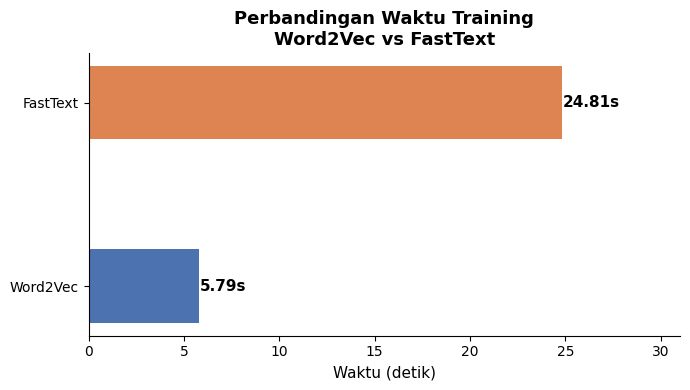

✅ Gambar disimpan: nb_images/waktu_training_w2v_ft.png


In [44]:
# ── Visualisasi Waktu Training Word2Vec vs FastText ───────────────────────────
os.makedirs('nb_images', exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))

models = ['Word2Vec', 'FastText']
waktu = [waktu_w2v, waktu_ft]
colors = ['#4C72B0', '#DD8452']

bars = ax.barh(models, waktu, color=colors, height=0.4)

for bar, val in zip(bars, waktu):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}s', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Waktu (detik)', fontsize=11)
ax.set_title('Perbandingan Waktu Training\nWord2Vec vs FastText', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(waktu) * 1.25)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('nb_images/waktu_training_w2v_ft.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: nb_images/waktu_training_w2v_ft.png")

Visualsiasi Clusteri (Scatter Plot)

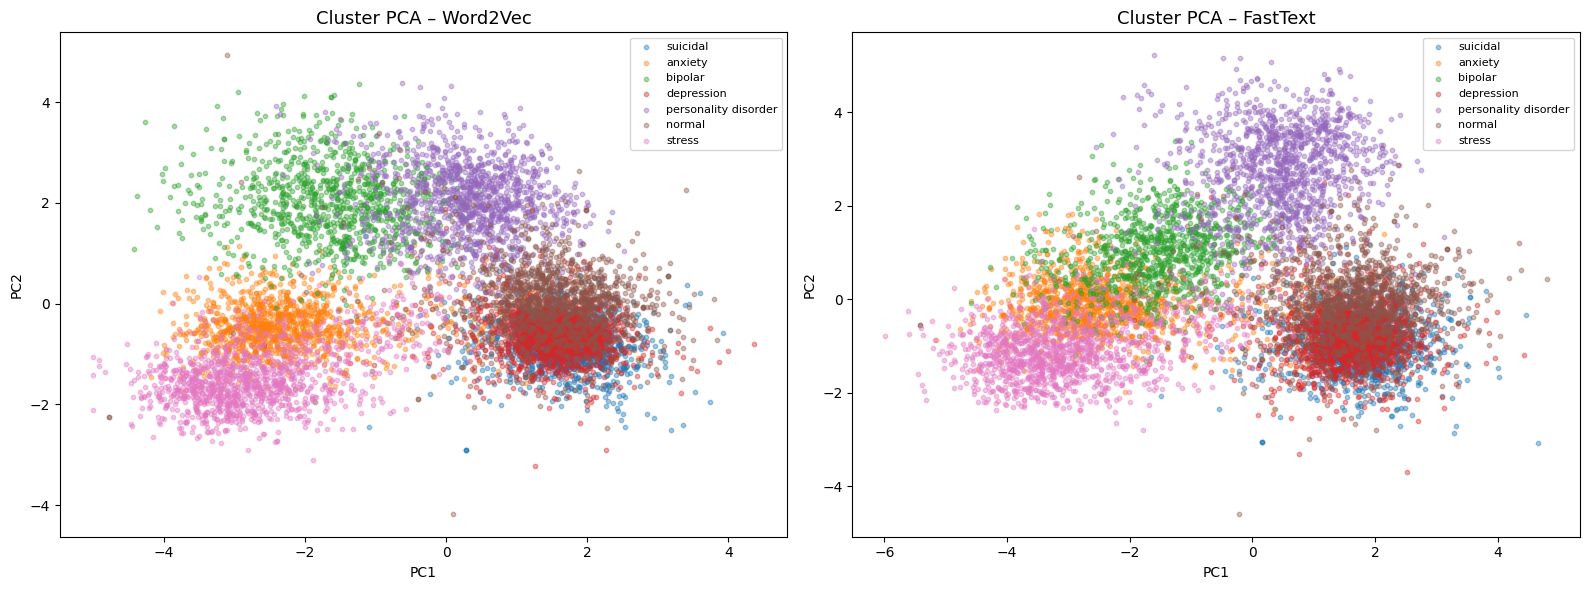

✅ Visualisasi cluster selesai!


In [45]:
# Visualisasi Cluster (PCA)

vecs_w2v_all = np.vstack(df['vector_w2v'].values)
vecs_ft_all  = np.vstack(df['vector_ft'].values)
labels       = df['status'].values

pca = PCA(n_components=2, random_state=42)
w2v_2d = pca.fit_transform(vecs_w2v_all)
ft_2d  = pca.fit_transform(vecs_ft_all)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
unique_labels = df['status'].unique()
colors = plt.cm.tab10.colors

for ax, data_2d, title in zip(axes, [w2v_2d, ft_2d], ['Word2Vec', 'FastText']):
    for i, label in enumerate(unique_labels):
        idx = labels == label
        ax.scatter(data_2d[idx, 0], data_2d[idx, 1],
                   label=label, alpha=0.4, s=10, color=colors[i])
    ax.set_title(f'Cluster PCA – {title}', fontsize=13)
    ax.legend(fontsize=8)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('nb_images/cluster_pca.png', dpi=150)
plt.show()
print("✅ Visualisasi cluster selesai!")

Mengecek Silhouette Score

In [46]:
# Silhouette Score

le = LabelEncoder()
y_encoded = le.fit_transform(df['status'].values)

score_w2v = silhouette_score(vecs_w2v_all, y_encoded, sample_size=1000, random_state=42)
score_ft  = silhouette_score(vecs_ft_all,  y_encoded, sample_size=1000, random_state=42)

print("=" * 40)
print("       SILHOUETTE SCORE")
print("=" * 40)
print(f"  Word2Vec : {score_w2v:.4f}")
print(f"  FastText : {score_ft:.4f}")
print("=" * 40)

       SILHOUETTE SCORE
  Word2Vec : 0.1525
  FastText : 0.1473


### Ringkasan

In [47]:
# Tabel Ringkasan
df_summary = pd.DataFrame({
    'Metrik'   : ['Waktu Training (detik)', 'Silhouette Score', 'Ukuran Vocabulary'],
    'Word2Vec' : [round(waktu_w2v, 2), round(score_w2v, 4), len(model_w2v.wv)],
    'FastText' : [round(waktu_ft, 2),  round(score_ft, 4),  len(model_ft.wv)],
})

print("=" * 50)
print("        TABEL RINGKASAN PERBANDINGAN")
print("=" * 50)
print(df_summary.to_string(index=False))
print("=" * 50)

best = 'FastText' if score_ft > score_w2v else 'Word2Vec'
print(f"\n✅ Kesimpulan: {best} menghasilkan cluster yang lebih baik pada dataset ini.")

        TABEL RINGKASAN PERBANDINGAN
                Metrik  Word2Vec  FastText
Waktu Training (detik)    5.7900   24.8100
      Silhouette Score    0.1525    0.1473
     Ukuran Vocabulary 4106.0000 4106.0000

✅ Kesimpulan: Word2Vec menghasilkan cluster yang lebih baik pada dataset ini.


## **Eksploratory Data Analysis (EDA)**

In [48]:
df = pd.read_csv('clean_processed.csv')

KOLOM_TOKEN = 'text_preprocessed'
KOLOM_LABEL = 'status'

# Konversi string → list jika belum
df[KOLOM_TOKEN] = df[KOLOM_TOKEN].apply(
    lambda x: x.split() if isinstance(x, str) else x
)

print("✅ Kolom:", df.columns.tolist())
print("✅ Shape:", df.shape)
df.head()

✅ Kolom: ['text', 'status', 'length', 'clean_text', 'lower', 'normalized', 'tokens', 'text_no_stopword', 'text_stemmed', 'text_preprocessed']
✅ Shape: (9151, 10)


,text,status,length,clean_text,lower,normalized,tokens,text_no_stopword,text_stemmed,text_preprocessed
0,Saya tidak tahu apakah ini kedengarannya bodoh...,suicidal,1207,Saya tidak tahu apakah ini kedengarannya bodoh...,saya tidak tahu apakah ini kedengarannya bodoh...,saya tidak tahu apakah ini kedengarannya bodoh...,"['saya', 'tidak', 'tahu', 'apakah', 'ini', 'ke...",kedengarannya bodoh gunanya mencoba mencapai u...,dengar bodoh guna coba capai usia dewasa dunia...,"[dengar, bodoh, guna, coba, capai, usia, dewas..."
1,"pikiranku bagaikan badai yang kacau, melempark...",anxiety,151,pikiranku bagaikan badai yang kacau melemparka...,pikiranku bagaikan badai yang kacau melemparka...,pikiranku bagaikan badai yang kacau melemparka...,"['pikiranku', 'bagaikan', 'badai', 'yang', 'ka...",pikiranku badai kacau melemparkanku penyesalan...,pikir badai kacau lempar sesal takut buat daya...,"[pikir, badai, kacau, lempar, sesal, takut, bu..."
2,Pada suatu saat saya dilanda gelombang kreativ...,bipolar,226,Pada suatu saat saya dilanda gelombang kreativ...,pada suatu saat saya dilanda gelombang kreativ...,pada suatu saat saya dilanda gelombang kreativ...,"['pada', 'suatu', 'saat', 'saya', 'dilanda', '...",dilanda gelombang kreativitas produktivitas di...,landa gelombang kreativitas produktivitas land...,"[landa, gelombang, kreativitas, produktivitas,..."
3,"jadi teman saya sedang mengalami masa sulit, d...",depression,802,jadi teman saya sedang mengalami masa sulit di...,jadi teman saya sedang mengalami masa sulit di...,jadi teman saya sedang mengalami masa sulit di...,"['jadi', 'teman', 'saya', 'sedang', 'mengalami...",teman mengalami sulit bantuan dukungan memutus...,teman alami sulit bantu dukung putus tulis pui...,"[teman, alami, sulit, bantu, dukung, putus, tu..."
4,Aku terpecah antara siapa aku sebenarnya dan i...,personality disorder,148,Aku terpecah antara siapa aku sebenarnya dan i...,aku terpecah antara siapa aku sebenarnya dan i...,saya terpecah antara siapa saya sebenarnya dan...,"['saya', 'terpecah', 'antara', 'siapa', 'saya'...",terpecah emosiku asli topeng lepas,pecah emosi asli topeng lepas,"[pecah, emosi, asli, topeng, lepas]"


### Ringkasan Dataset

In [49]:
# ──  Ringkasan dataset

print("=" * 55)
print("  RINGKASAN DATASET CORTISOUL")
print("=" * 55)

print(f"\nJumlah entri       : {len(df):,}")
print(f"Jumlah kolom       : {df.shape[1]}")
print(f"Jumlah kondisi     : {df[KOLOM_LABEL].nunique()}")
print(f"Missing value teks : {df[KOLOM_TOKEN].isna().sum()}")
print(f"Duplikat teks      : {df[KOLOM_TOKEN].duplicated().sum()}")

print(f"\nDistribusi kondisi mental:")
vc = df[KOLOM_LABEL].value_counts()
for kondisi, jumlah in vc.items():
    pct  = jumlah / len(df) * 100
    bar  = '█' * int(pct / 2)
    print(f"  {kondisi:<22} {jumlah:>5}  ({pct:5.1f}%)  {bar}")

  RINGKASAN DATASET CORTISOUL

Jumlah entri       : 9,151
Jumlah kolom       : 10
Jumlah kondisi     : 7
Missing value teks : 8
Duplikat teks      : 68

Distribusi kondisi mental:
  suicidal                1657  ( 18.1%)  █████████
  depression              1635  ( 17.9%)  ████████
  normal                  1236  ( 13.5%)  ██████
  personality disorder    1234  ( 13.5%)  ██████
  stress                  1233  ( 13.5%)  ██████
  anxiety                 1190  ( 13.0%)  ██████
  bipolar                  966  ( 10.6%)  █████


### Distribusi Kelas

✅ Gambar berhasil disimpan: distribusi_kondisi_mental.png


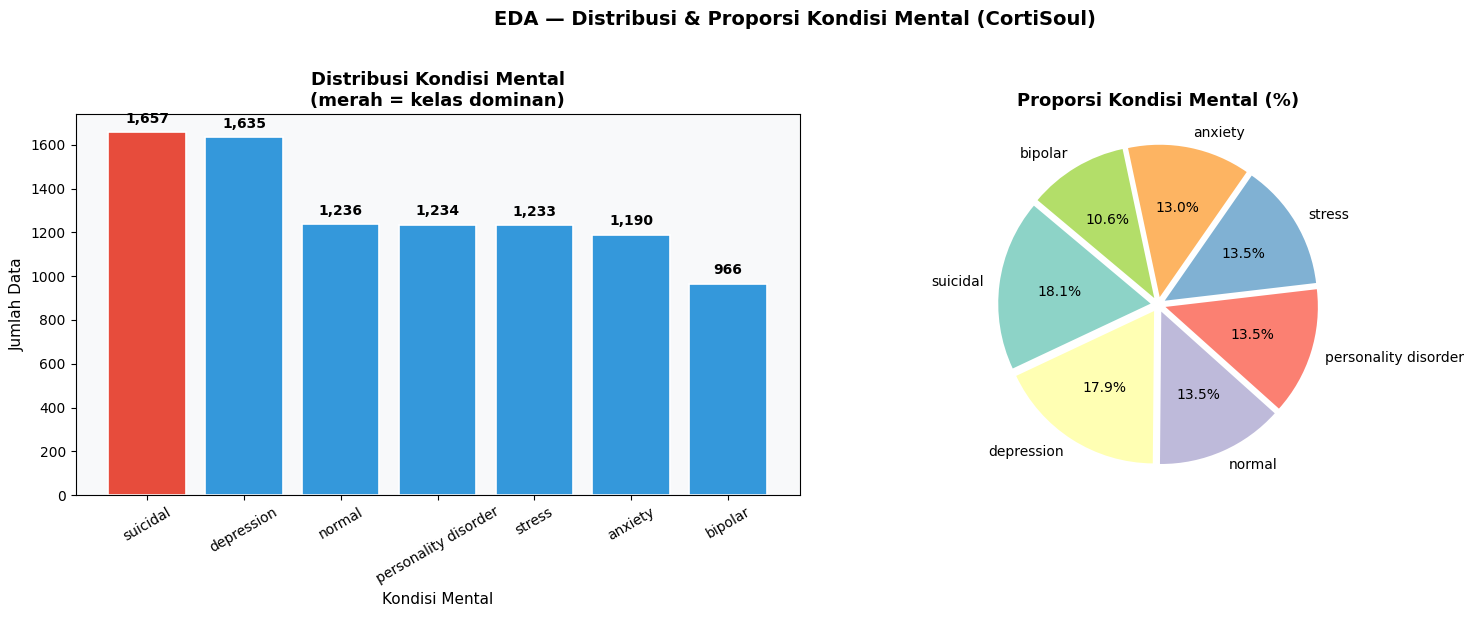


📊 Analisis Class Imbalance:
  Kelas terbanyak : suicidal (1,657)
  Kelas tersedikit: bipolar (966)
  Rasio imbalance : 1 : 1.72
  ✅ Imbalance ringan (rasio ≤ 1:3) — masih bisa dilatih langsung


In [50]:
# ──  Distribusi kelas + deteksi class imbalance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

kondisi_order = df[KOLOM_LABEL].value_counts().index.tolist()
jumlah_order  = df[KOLOM_LABEL].value_counts().values.tolist()
warna_bar     = ['#e74c3c' if j == max(jumlah_order) else '#3498db'
                 for j in jumlah_order]

# Bar chart
bars = axes[0].bar(kondisi_order, jumlah_order,
                   color=warna_bar, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Kondisi Mental\n(merah = kelas dominan)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kondisi Mental', fontsize=11)
axes[0].set_ylabel('Jumlah Data', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, jumlah_order):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].set_facecolor('#f8f9fa')

# Pie chart
explode = [0.05] * len(kondisi_order)
axes[1].pie(
    jumlah_order,
    labels=kondisi_order,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    colors=plt.cm.Set3.colors[:len(kondisi_order)]
)
axes[1].set_title('Proporsi Kondisi Mental (%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('EDA — Distribusi & Proporsi Kondisi Mental (CortiSoul)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan gambar
plt.savefig('nb_images/distribusi_kondisi_mental.png', dpi=300, bbox_inches='tight')
print("✅ Gambar berhasil disimpan: distribusi_kondisi_mental.png")

plt.show()

# Analisis class imbalance
print("\n📊 Analisis Class Imbalance:")
kelas_max = vc.index[0]
kelas_min = vc.index[-1]
rasio     = vc[kelas_max] / vc[kelas_min]
print(f"  Kelas terbanyak : {kelas_max} ({vc[kelas_max]:,})")
print(f"  Kelas tersedikit: {kelas_min} ({vc[kelas_min]:,})")
print(f"  Rasio imbalance : 1 : {rasio:.2f}")
if rasio > 3:
    print("  ⚠️  Imbalance SIGNIFIKAN (rasio > 1:3) — perlu SMOTE/oversampling")
else:
    print("  ✅ Imbalance ringan (rasio ≤ 1:3) — masih bisa dilatih langsung")

In [51]:
df = df.dropna(subset=['text_preprocessed'])
df = df.reset_index(drop=True)

### Top 20 kata paling sering muncul

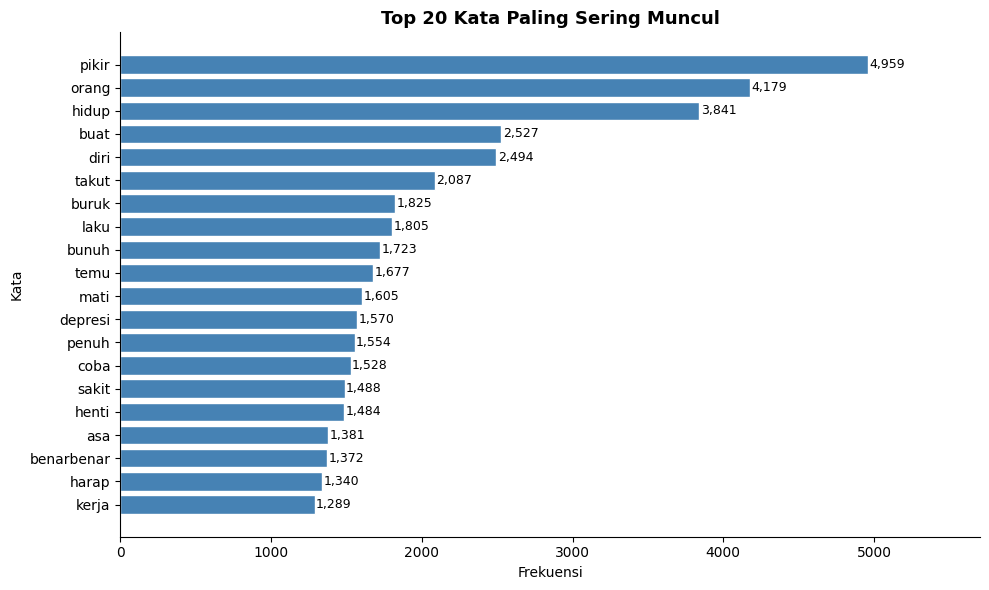

In [52]:
from collections import Counter
import ast

# Gabungkan semua tokens
all_tokens = []
for tokens in df['text_preprocessed']:
    if isinstance(tokens, str):
        tokens = ast.literal_eval(tokens)
    all_tokens.extend(tokens)

# Hitung frekuensi
word_freq = Counter(all_tokens)
top20 = word_freq.most_common(20)
kata, frekuensi = zip(*top20)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(list(kata)[::-1], list(frekuensi)[::-1], color='steelblue', edgecolor='white')
for bar, val in zip(bars, list(frekuensi)[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left', fontsize=9)

ax.set_title('Top 20 Kata Paling Sering Muncul', fontsize=13, fontweight='bold')
ax.set_xlabel('Frekuensi')
ax.set_ylabel('Kata')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(frekuensi) * 1.15)

plt.tight_layout()
plt.savefig('nb_images/eda_top20_kata.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# Hapus teks dengan kurang dari 3 kata
sebelum = len(df)
df = df[df['tokens'].apply(lambda x: len(x) >= 3)].reset_index(drop=True)
sesudah = len(df)

print(f"✅ Data sebelum filter : {sebelum} baris")
print(f"✅ Data setelah filter : {sesudah} baris")
print(f"🗑️  Dihapus            : {sebelum - sesudah} baris")

✅ Data sebelum filter : 9143 baris
✅ Data setelah filter : 9143 baris
🗑️  Dihapus            : 0 baris


### Distribusi Panjang Teks

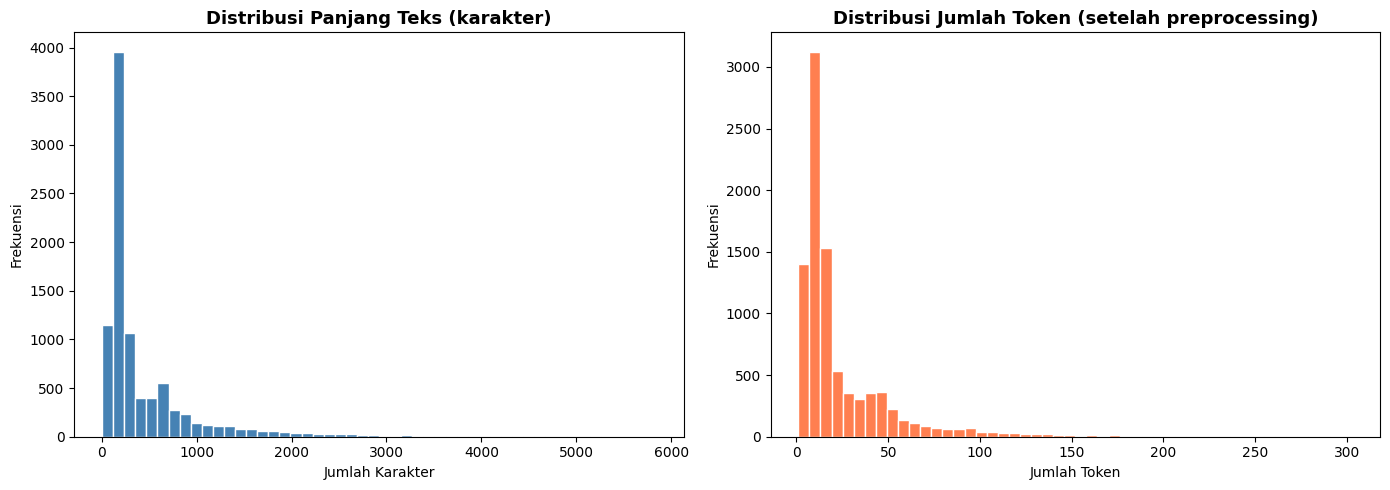

In [54]:
import ast

# Hitung panjang teks asli dan hasil preprocessing
df['panjang_teks'] = df['lower'].apply(len)

# Karena text_preprocessed berbentuk list, langsung pakai len()
df['panjang_bersih'] = df['text_preprocessed'].apply(
    lambda x: len(x) if isinstance(x, list)
    else len(ast.literal_eval(x)) if isinstance(x, str)
    else 0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi panjang karakter
axes[0].hist(df['panjang_teks'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Teks (karakter)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')

# Distribusi jumlah token
axes[1].hist(df['panjang_bersih'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Token (setelah preprocessing)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Token')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('nb_images/eda_distribusi_panjang.png', dpi=150, bbox_inches='tight')
plt.show()

### Panjang Text Per kondisi mental

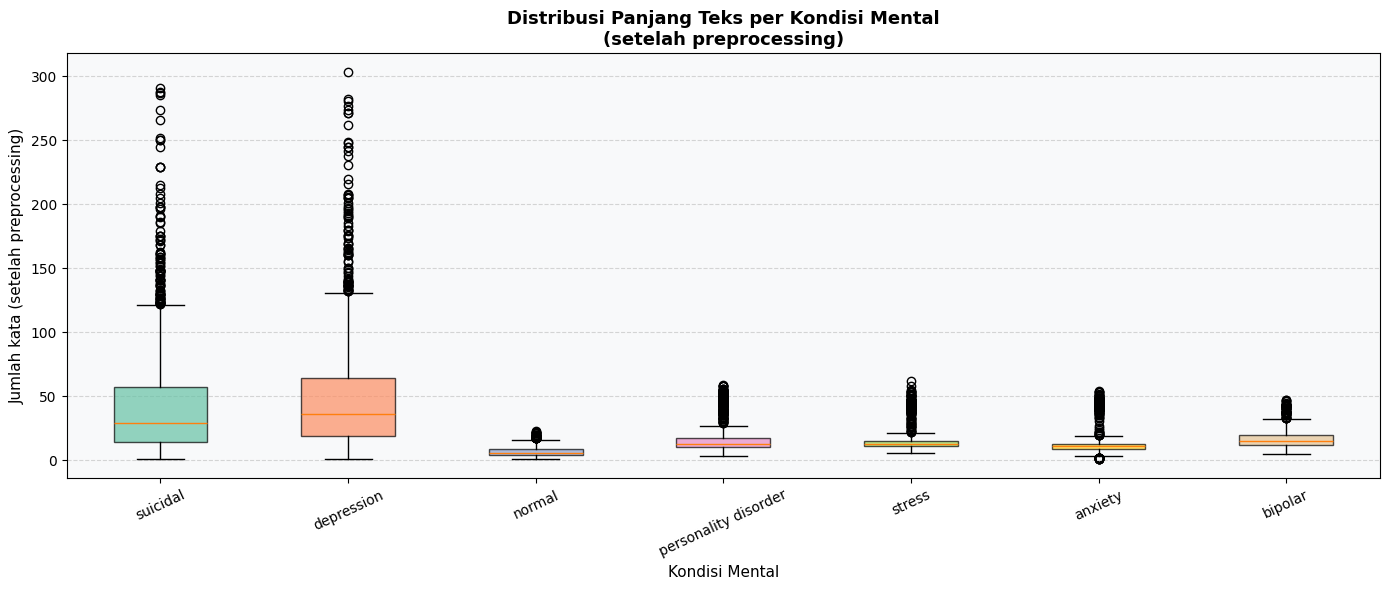

📊 Median panjang teks per kondisi:
  suicidal                  29 kata
  depression                36 kata
  normal                    6 kata
  personality disorder      13 kata
  stress                    13 kata
  anxiety                   11 kata
  bipolar                   15 kata


In [55]:
# ──  Panjang teks per kondisi mental (boxplot)

fig, ax = plt.subplots(figsize=(14, 6))

data_box  = [df[df[KOLOM_LABEL] == k]['panjang_bersih'].values
             for k in kondisi_order]
bp = ax.boxplot(data_box, labels=kondisi_order, patch_artist=True,
                notch=False, vert=True)

colors_box = plt.cm.Set2.colors[:len(kondisi_order)]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribusi Panjang Teks per Kondisi Mental\n(setelah preprocessing)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Kondisi Mental', fontsize=11)
ax.set_ylabel('Jumlah kata (setelah preprocessing)', fontsize=11)
ax.tick_params(axis='x', rotation=25)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nb_images/eda_boxplot_panjang_per_kondisi.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Median panjang teks per kondisi:")
for k in kondisi_order:
    med = df[df[KOLOM_LABEL] == k]['panjang_bersih'].median()
    print(f"  {k:<25} {med:.0f} kata")

## **🎯 Business Questions**

Berdasarkan permasalahan tersebut, dirumuskan pertanyaan bisnis sebagai berikut:

1. Token atau frasa apa yang paling merepresentasikan masing-masing dari 7 kategori kondisi mental, berdasarkan analisis Word2Vec dan FastText (top-10 kata paling mirip per kategori) pada dataset 9.151 entri CortiSoul yang telah melalui preprocessing Sastrawi + stopword removal + stemming, sebagai dasar feature engineering dan interpretasi model selama fase EDA proyek CortiSoul?

2. Bagaimana model NLP menggunakan representasi vektor Word2Vec dan FastText (vector_size=100, window=5) dapat mengklasifikasikan 7 kondisi mental (Anxiety, Normal, Depression, Stress, Personality Disorder, Bipolar, Suicidal) dari teks journaling berbahasa Indonesia dengan akurasi minimal 80% dan F1-score ≥ 0,75 pada dataset 9.151 entri hasil preprocessing Sastrawi, selama fase pemodelan pada periode pengembangan proyek CortiSoul?

# **PERTANYAAN 1** : Token atau frasa apa yang paling merepresentasikan masing-masing dari 7 kategori kondisi mental, berdasarkan analisis Word2Vec dan FastText (top-10 kata paling mirip per kategori) pada dataset 9.151 entri CortiSoul yang telah melalui preprocessing Sastrawi + stopword removal + stemming, sebagai dasar feature engineering dan interpretasi model selama fase EDA proyek CortiSoul?

## **Eksploratory Data Analysis**

In [56]:
# ── [Pertanyaan 1] Top-10 kata representatif per kondisi

kondisi_list = df[KOLOM_LABEL].unique().tolist()
print(f"7 kondisi mental: {kondisi_list}\n")

# Debug: cek tipe data kolom token
print("Tipe data sample:", type(df[KOLOM_TOKEN].dropna().iloc[0]))
print("Contoh isi:", df[KOLOM_TOKEN].dropna().iloc[0][:5])
print()

hasil_w2v = {}
hasil_ft  = {}

for kondisi in kondisi_list:
    semua_token = []
    for tokens in df[df[KOLOM_LABEL] == kondisi][KOLOM_TOKEN].dropna():
        if isinstance(tokens, list):
            semua_token.extend(tokens)

    freq = Counter(semua_token)
    kata_kondisi = [k for k, _ in freq.most_common(50) if k in model_w2v.wv]

    # Debug per kondisi
    print(f"{kondisi} → total token: {len(semua_token)}, kata di vocab: {len(kata_kondisi)}")

    if not kata_kondisi:
        print(f"  ⚠️ tidak ada kata di vocabulary\n")
        continue

    anchor_w2v = kata_kondisi[:5]
    anchor_ft  = [k for k in kata_kondisi[:5] if k in model_ft.wv]

    similar_w2v = model_w2v.wv.most_similar(positive=anchor_w2v, topn=10)
    similar_ft  = model_ft.wv.most_similar(positive=anchor_ft,  topn=10)

    hasil_w2v[kondisi] = similar_w2v
    hasil_ft[kondisi]  = similar_ft

print("\n✅ Debug selesai!")

7 kondisi mental: ['suicidal', 'anxiety', 'bipolar', 'depression', 'personality disorder', 'normal', 'stress']

Tipe data sample: <class 'list'>
Contoh isi: ['dengar', 'bodoh', 'guna', 'coba', 'capai']

suicidal → total token: 71362, kata di vocab: 50
anxiety → total token: 17181, kata di vocab: 50
bipolar → total token: 16290, kata di vocab: 50
depression → total token: 79820, kata di vocab: 50
personality disorder → total token: 21582, kata di vocab: 50
normal → total token: 8075, kata di vocab: 50
stress → total token: 19218, kata di vocab: 50

✅ Debug selesai!


### Top 10 Per Kondisi Mental

In [57]:
# ── [Pertanyaan 1] Tabel top-10 per kondisi

rows = []
for kondisi in kondisi_list:
    if kondisi not in hasil_w2v:
        continue
    for rank, ((kw, sw), (kf, sf)) in enumerate(zip(hasil_w2v[kondisi], hasil_ft[kondisi]), 1):
        rows.append({
            'Kondisi Mental' : kondisi,
            'Rank'           : rank,
            'Token W2V'      : kw,
            'Skor W2V'       : round(sw, 4),
            'Token FT'       : kf,
            'Skor FT'        : round(sf, 4),
        })

df_hasil = pd.DataFrame(rows)

pivot = df_hasil.pivot_table(
    index='Rank',
    columns='Kondisi Mental',
    values='Token W2V',
    aggfunc='first'
)
print("Tabel Top-10 Token per Kondisi Mental (Word2Vec):")
print(pivot.to_string())

df_hasil.to_csv('top10_w2v_ft_per_kondisi.csv', index=False)
print("\n✅ Disimpan ke: top10_w2v_ft_per_kondisi.csv")

Tabel Top-10 Token per Kondisi Mental (Word2Vec):
Kondisi Mental         anxiety        bipolar depression       normal personality disorder      stress  suicidal
Rank                                                                                                            
1                         ragu           lesu     obsesi        palsu                versi      rentet     kecut
2                      gerogot          kurun   sengsara         duka               pegang     tenggat  sengsara
3                        kuasa      optimisme      logis       berani                fasad       wajib    takdir
4               pikiranpikiran     antusiasme     takdir         sepi                ilusi      imbang     egois
5                         asai          landa     serius      sungguh                pecah      tumpuk   fantasi
6                  konsekuensi     meluapluap      kecut   siapasiapa                 nali      tuntut      alas
7                        tawan  produktivitas 

### Word Cloud Per Kondisi

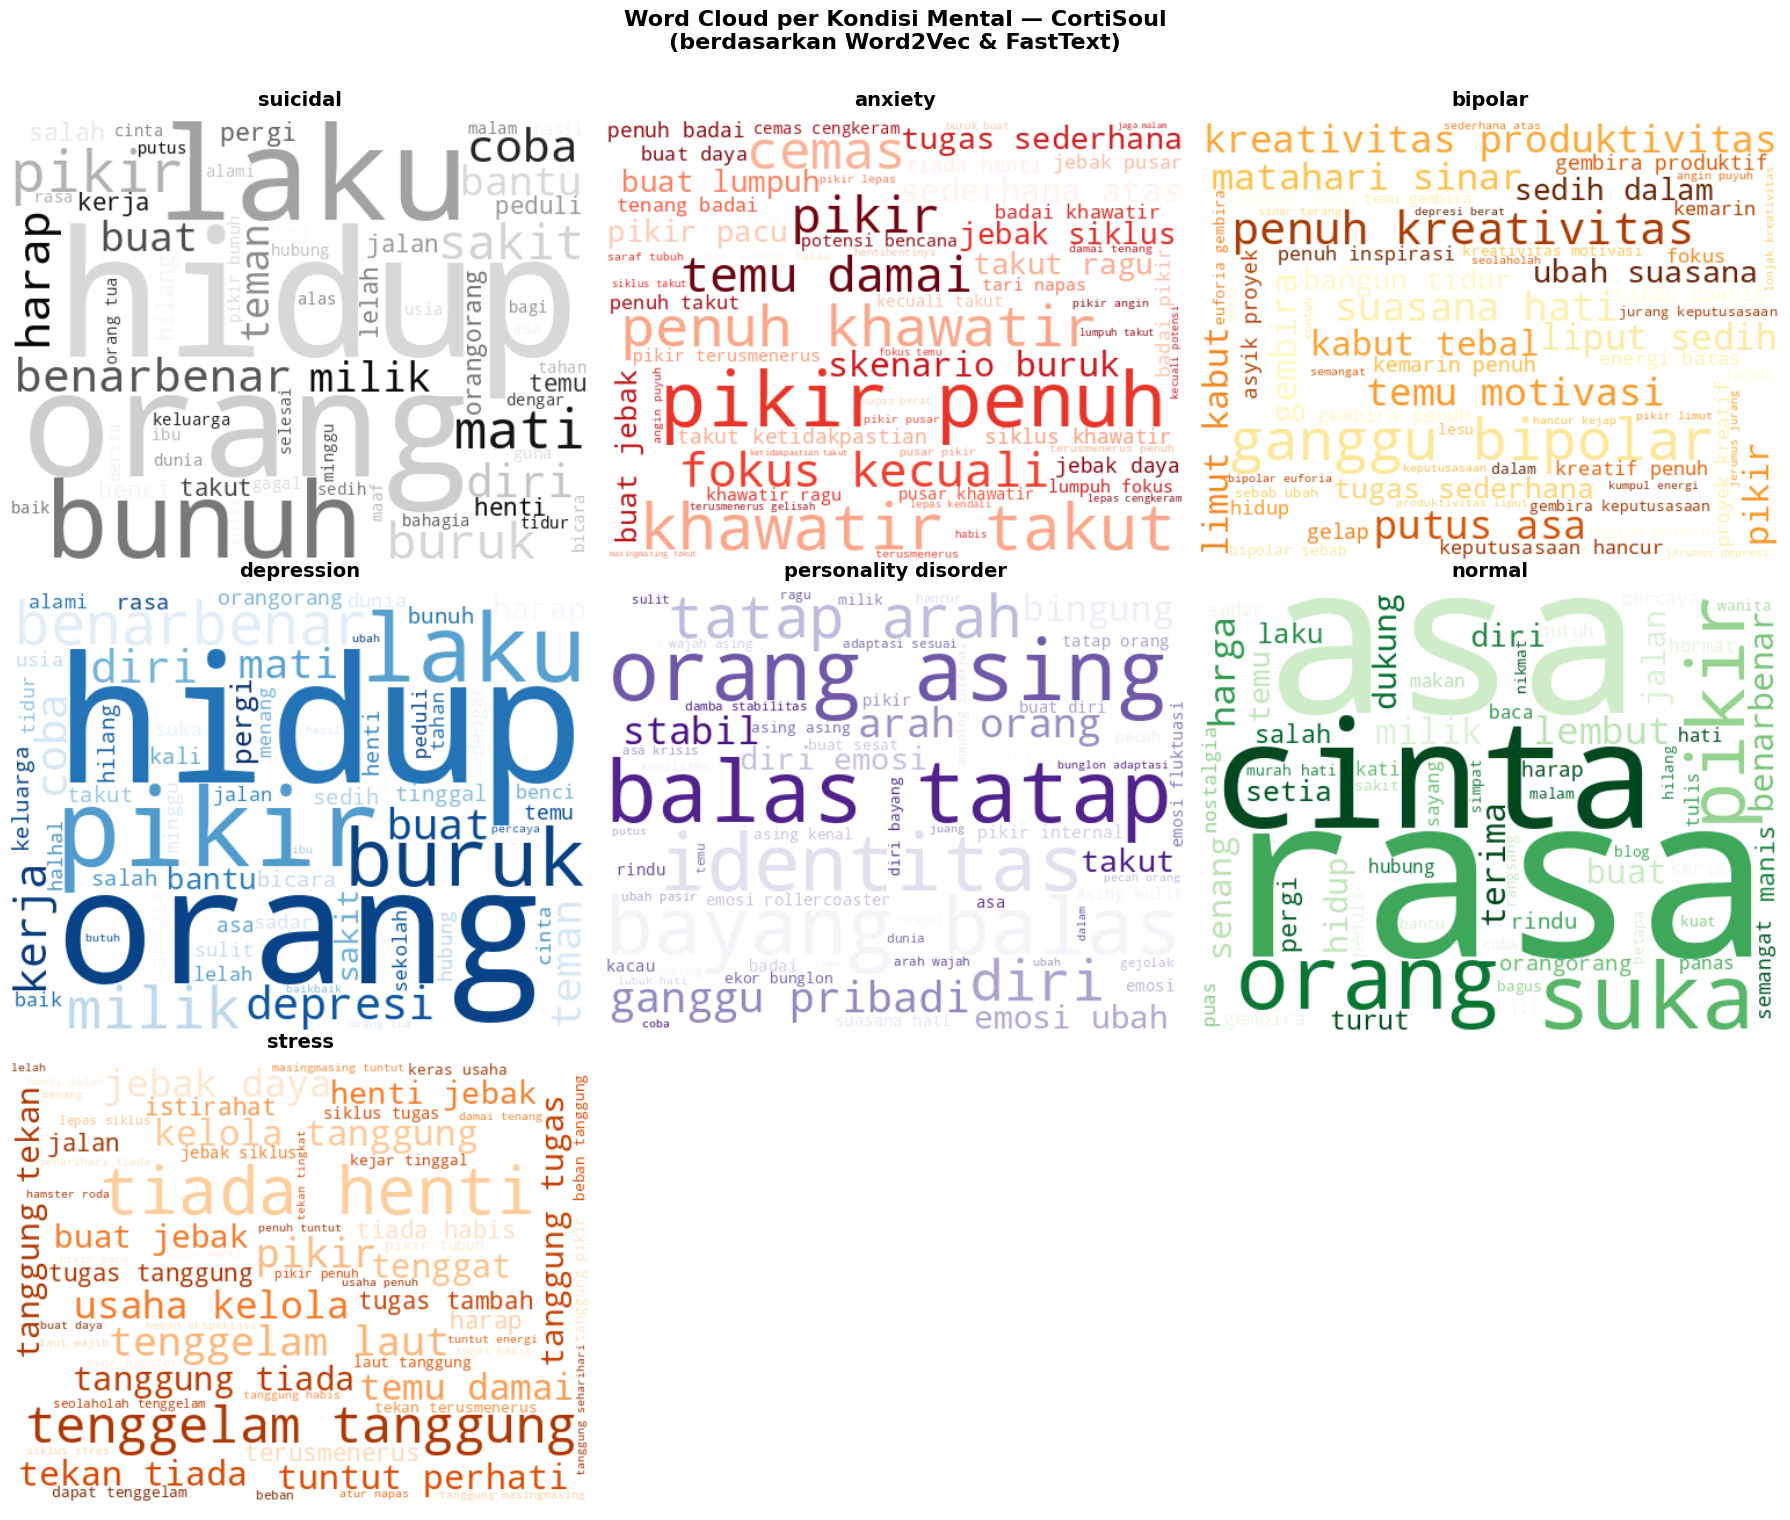

✅ Word cloud disimpan ke: nb_images/wordcloud_kondisi_mental.png


In [58]:
# ── [Pertanyaan 1] Word Cloud per kondisi

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

warna_map = {
    'anxiety'             : 'Reds',
    'normal'              : 'Greens',
    'depression'          : 'Blues',
    'stress'              : 'Oranges',
    'personality disorder': 'Purples',
    'bipolar'             : 'YlOrBr',
    'suicidal'            : 'Greys',
}

for i, kondisi in enumerate(kondisi_list):
    # Gabungkan tokens_list jadi string
    teks_gabung = ' '.join([
        ' '.join(t) if isinstance(t, list) else t
        for t in df[df[KOLOM_LABEL] == kondisi][KOLOM_TOKEN].dropna()
    ])

    colormap = warna_map.get(kondisi.lower(), 'viridis')

    wc = WordCloud(
        width=500, height=380,
        background_color='white',
        max_words=60,
        colormap=colormap,
        collocations=True,
        prefer_horizontal=0.85
    ).generate(teks_gabung if teks_gabung.strip() else "tidak ada data")

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(kondisi, fontsize=14, fontweight='bold', pad=10)
    axes[i].axis('off')

for j in range(len(kondisi_list), len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'Word Cloud per Kondisi Mental — CortiSoul\n(berdasarkan Word2Vec & FastText)',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('nb_images/wordcloud_kondisi_mental.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word cloud disimpan ke: nb_images/wordcloud_kondisi_mental.png")

### Validasi Volcabulary

In [59]:
# ── [Pertanyaan 1] Validasi vocabulary

print("=" * 55)
print("  VALIDASI VOCABULARY W2V & FASTTEXT")
print("=" * 55)

# Vocab global
semua_token_global = []
for tokens in df[KOLOM_TOKEN].dropna():
    if isinstance(tokens, list):
        semua_token_global.extend(tokens)
    else:
        semua_token_global.extend(tokens.split())

vocab_global = set(semua_token_global)
vocab_w2v    = set(model_w2v.wv.key_to_index.keys())
vocab_ft     = set(model_ft.wv.key_to_index.keys())

print(f"\nTotal token unik di corpus   : {len(vocab_global):,}")
print(f"Vocabulary Word2Vec          : {len(vocab_w2v):,}")
print(f"Vocabulary FastText          : {len(vocab_ft):,}")

print("\nJumlah token unik per kondisi mental:")
for kondisi in kondisi_list:
    token_kondisi = []
    for tokens in df[df[KOLOM_LABEL] == kondisi][KOLOM_TOKEN].dropna():
        if isinstance(tokens, list):
            token_kondisi.extend(tokens)
        else:
            token_kondisi.extend(tokens.split())
    vocab_k   = set(token_kondisi)
    in_w2v    = len(vocab_k & vocab_w2v)
    in_ft     = len(vocab_k & vocab_ft)
    print(f"  {kondisi:<25} unik: {len(vocab_k):>5}   "
          f"ada di W2V: {in_w2v:>4}   ada di FT: {in_ft:>4}")

  VALIDASI VOCABULARY W2V & FASTTEXT

Total token unik di corpus   : 7,177
Vocabulary Word2Vec          : 4,106
Vocabulary FastText          : 4,106

Jumlah token unik per kondisi mental:
  suicidal                  unik:  4312   ada di W2V: 3258   ada di FT: 3258
  anxiety                   unik:   868   ada di W2V:  786   ada di FT:  786
  bipolar                   unik:   780   ada di W2V:  756   ada di FT:  756
  depression                unik:  4629   ada di W2V: 3394   ada di FT: 3394
  personality disorder      unik:  1413   ada di W2V: 1279   ada di FT: 1279
  normal                    unik:  2168   ada di W2V: 1694   ada di FT: 1694
  stress                    unik:  1189   ada di W2V: 1121   ada di FT: 1121


## **Visualisasi dan Eksplanatory Data Analysis**

  PERTANYAAN 1 — POLA KATA PER KONDISI MENTAL (Word2Vec)


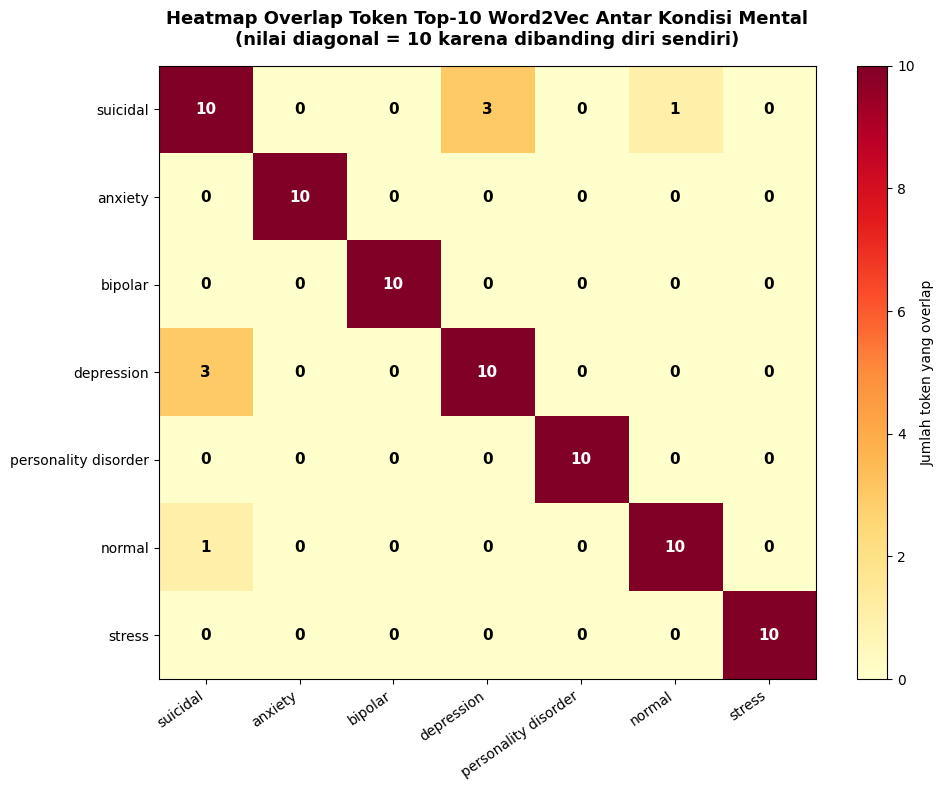


📊 Interpretasi Overlap Token:
--------------------------------------------------
  suicidal vs anxiety: TIDAK ADA overlap → token sangat unik
  suicidal vs bipolar: TIDAK ADA overlap → token sangat unik
  ⚠️  suicidal vs depression: 3 token sama → perlu perhatian
  suicidal vs personality disorder: TIDAK ADA overlap → token sangat unik
  suicidal vs normal: 1 token sama → cukup berbeda
  suicidal vs stress: TIDAK ADA overlap → token sangat unik
  anxiety vs bipolar: TIDAK ADA overlap → token sangat unik
  anxiety vs depression: TIDAK ADA overlap → token sangat unik
  anxiety vs personality disorder: TIDAK ADA overlap → token sangat unik
  anxiety vs normal: TIDAK ADA overlap → token sangat unik
  anxiety vs stress: TIDAK ADA overlap → token sangat unik
  bipolar vs depression: TIDAK ADA overlap → token sangat unik
  bipolar vs personality disorder: TIDAK ADA overlap → token sangat unik
  bipolar vs normal: TIDAK ADA overlap → token sangat unik
  bipolar vs stress: TIDAK ADA overlap → 

In [60]:
# ── [Pertanyaan 1] Heatmap overlap token — Word2Ve

print("=" * 60)
print("  PERTANYAAN 1 — POLA KATA PER KONDISI MENTAL (Word2Vec)")
print("=" * 60)

kondisi_list = list(hasil_w2v.keys())

# Kumpulkan top-10 token per kondisi ke set
top10_sets = {}
for kondisi, pairs in hasil_w2v.items():
    top10_sets[kondisi] = set([kata for kata, _ in pairs])

# Hitung overlap
n = len(kondisi_list)
matrix_overlap = np.zeros((n, n), dtype=int)

for i, k1 in enumerate(kondisi_list):
    for j, k2 in enumerate(kondisi_list):
        matrix_overlap[i][j] = len(top10_sets[k1] & top10_sets[k2])

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix_overlap, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(kondisi_list, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(kondisi_list, fontsize=10)

for i in range(n):
    for j in range(n):
        val   = matrix_overlap[i][j]
        warna = 'white' if val > 5 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=11, fontweight='bold', color=warna)

plt.colorbar(im, ax=ax, label='Jumlah token yang overlap')
ax.set_title(
    'Heatmap Overlap Token Top-10 Word2Vec Antar Kondisi Mental\n'
    '(nilai diagonal = 10 karena dibanding diri sendiri)',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('nb_images/explain_A1_heatmap_overlap_token_w2v.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Interpretasi Overlap Token:")
print("-" * 50)
for i, k1 in enumerate(kondisi_list):
    for j, k2 in enumerate(kondisi_list):
        if i < j:
            ov = matrix_overlap[i][j]
            if ov == 0:
                print(f"  {k1} vs {k2}: TIDAK ADA overlap → token sangat unik")
            elif ov <= 2:
                print(f"  {k1} vs {k2}: {ov} token sama → cukup berbeda")
            else:
                print(f"  ⚠️  {k1} vs {k2}: {ov} token sama → perlu perhatian")

### Heatmap Overlap token - Fast Text

  PERTANYAAN 1 — POLA KATA PER KONDISI MENTAL (FastText)


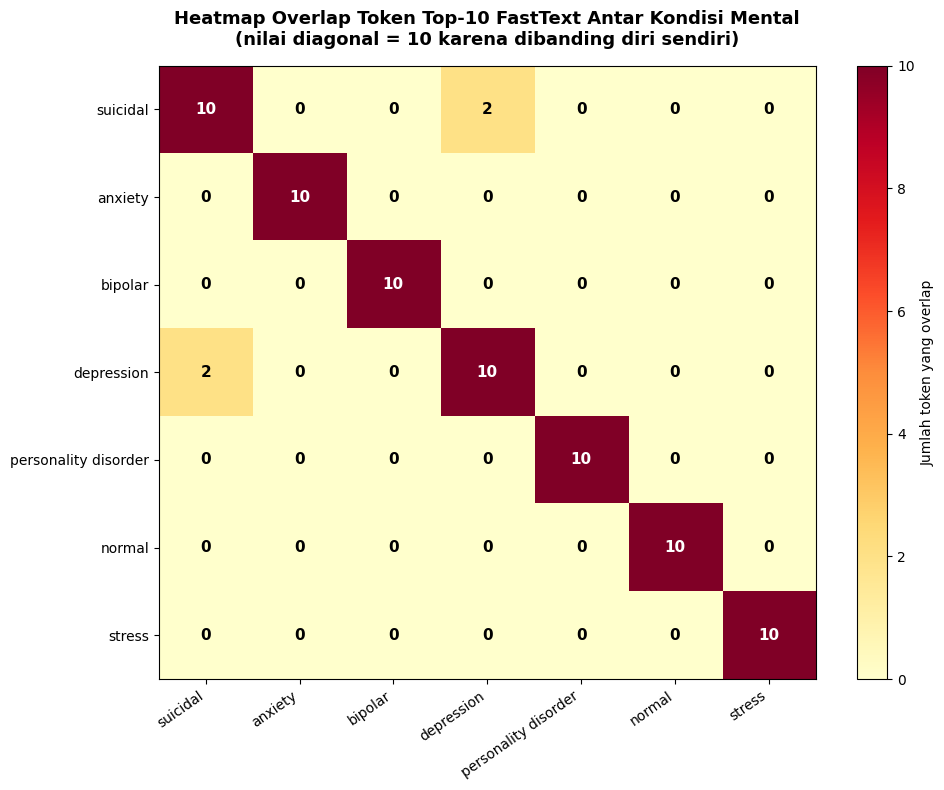


📊 Interpretasi Overlap Token (FastText):
--------------------------------------------------
  suicidal vs anxiety: TIDAK ADA overlap → token sangat unik
  suicidal vs bipolar: TIDAK ADA overlap → token sangat unik
  suicidal vs depression: 2 token sama → cukup berbeda
  suicidal vs personality disorder: TIDAK ADA overlap → token sangat unik
  suicidal vs normal: TIDAK ADA overlap → token sangat unik
  suicidal vs stress: TIDAK ADA overlap → token sangat unik
  anxiety vs bipolar: TIDAK ADA overlap → token sangat unik
  anxiety vs depression: TIDAK ADA overlap → token sangat unik
  anxiety vs personality disorder: TIDAK ADA overlap → token sangat unik
  anxiety vs normal: TIDAK ADA overlap → token sangat unik
  anxiety vs stress: TIDAK ADA overlap → token sangat unik
  bipolar vs depression: TIDAK ADA overlap → token sangat unik
  bipolar vs personality disorder: TIDAK ADA overlap → token sangat unik
  bipolar vs normal: TIDAK ADA overlap → token sangat unik
  bipolar vs stress: TIDAK 

In [61]:
# ── [Pertanyaan 1] Heatmap overlap token — FastText

print("=" * 60)
print("  PERTANYAAN 1 — POLA KATA PER KONDISI MENTAL (FastText)")
print("=" * 60)

kondisi_list_ft = list(hasil_ft.keys())

# Kumpulkan top-10 token per kondisi ke set
top10_sets_ft = {}
for kondisi, pairs in hasil_ft.items():
    top10_sets_ft[kondisi] = set([kata for kata, _ in pairs])

# Hitung overlap
n = len(kondisi_list_ft)
matrix_overlap_ft = np.zeros((n, n), dtype=int)

for i, k1 in enumerate(kondisi_list_ft):
    for j, k2 in enumerate(kondisi_list_ft):
        matrix_overlap_ft[i][j] = len(top10_sets_ft[k1] & top10_sets_ft[k2])

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix_overlap_ft, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(kondisi_list_ft, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(kondisi_list_ft, fontsize=10)

for i in range(n):
    for j in range(n):
        val   = matrix_overlap_ft[i][j]
        warna = 'white' if val > 5 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=11, fontweight='bold', color=warna)

plt.colorbar(im, ax=ax, label='Jumlah token yang overlap')
ax.set_title(
    'Heatmap Overlap Token Top-10 FastText Antar Kondisi Mental\n'
    '(nilai diagonal = 10 karena dibanding diri sendiri)',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('nb_images/explain_A1_heatmap_overlap_token_ft.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Interpretasi Overlap Token (FastText):")
print("-" * 50)
for i, k1 in enumerate(kondisi_list_ft):
    for j, k2 in enumerate(kondisi_list_ft):
        if i < j:
            ov = matrix_overlap_ft[i][j]
            if ov == 0:
                print(f"  {k1} vs {k2}: TIDAK ADA overlap → token sangat unik")
            elif ov <= 2:
                print(f"  {k1} vs {k2}: {ov} token sama → cukup berbeda")
            else:
                print(f"  ⚠️  {k1} vs {k2}: {ov} token sama → perlu perhatian")

### Bar Chart Top 10 Per Kondisi - Word2Vec


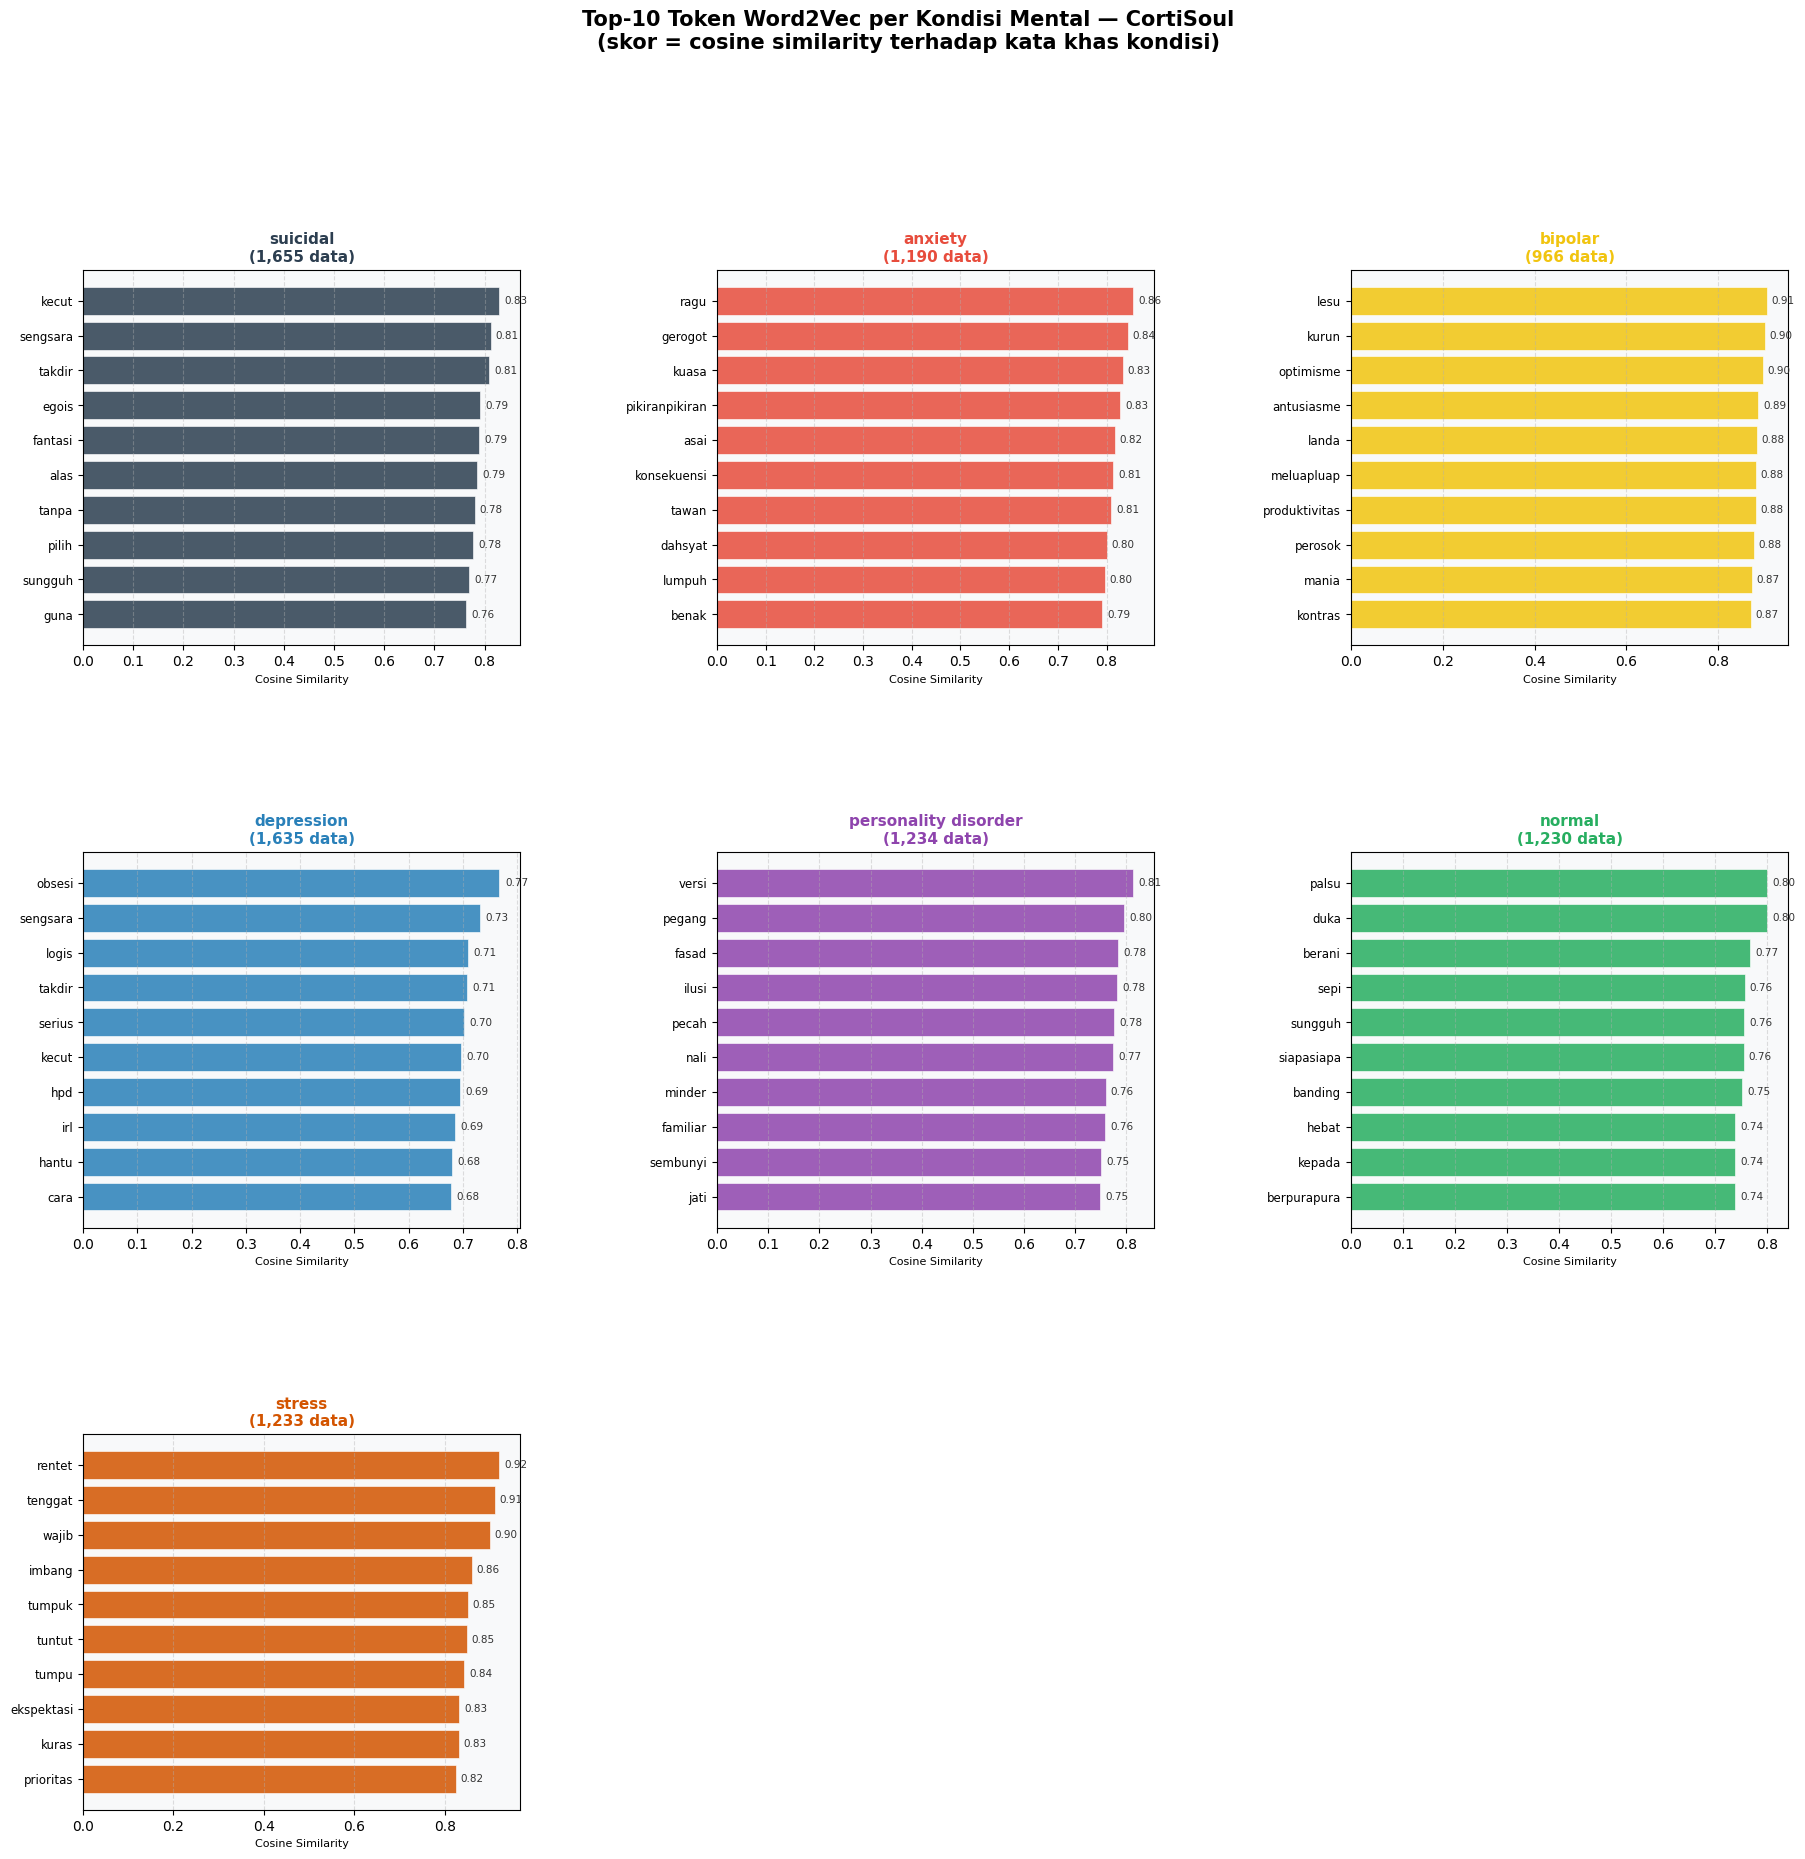

✅ Visualisasi top-10 Word2Vec per kondisi disimpan.


In [62]:
# ──── [Pertanyaan 1] Bar chart top-10 per kondisi (grid) — Word2Vec

PALETTE = {
    'anxiety':              '#e74c3c',
    'normal':               '#27ae60',
    'depression':           '#2980b9',
    'stress':               '#d35400',
    'personality disorder': '#8e44ad',
    'bipolar':              '#f1c40f',
    'suicidal':             '#2c3e50',
}

fig = plt.figure(figsize=(22, 20))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.45)

for idx, kondisi in enumerate(kondisi_list):
    row = idx // 3
    col = idx % 3
    ax  = fig.add_subplot(gs[row, col])

    pairs = hasil_w2v[kondisi]
    token = [p[0] for p in pairs]
    skor  = [p[1] for p in pairs]
    warna = PALETTE.get(kondisi, '#95a5a6')

    sorted_pairs = sorted(zip(token, skor), key=lambda x: x[1], reverse=True)
    token_s = [p[0] for p in sorted_pairs]
    skor_s  = [p[1] for p in sorted_pairs]

    bars = ax.barh(token_s, skor_s, color=warna, alpha=0.85,
                   edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, skor_s):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=7.5, color='#333')

    jumlah = df[KOLOM_LABEL].value_counts()[kondisi]
    ax.set_title(f'{kondisi}\n({jumlah:,} data)',
                 fontsize=11, fontweight='bold', color=warna, pad=6)
    ax.set_xlabel('Cosine Similarity', fontsize=8)
    ax.tick_params(axis='y', labelsize=8.5)
    ax.set_facecolor('#f8f9fa')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.invert_yaxis()

for idx in range(len(kondisi_list), 9):
    fig.add_subplot(gs[idx // 3, idx % 3]).axis('off')

fig.suptitle(
    'Top-10 Token Word2Vec per Kondisi Mental — CortiSoul\n'
    '(skor = cosine similarity terhadap kata khas kondisi)',
    fontsize=15, fontweight='bold', y=1.01
)
plt.savefig('nb_images/explain_A2_top10_w2v_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi top-10 Word2Vec per kondisi disimpan.")

### Bar Chart Top 10 Per Kondisi - FastText

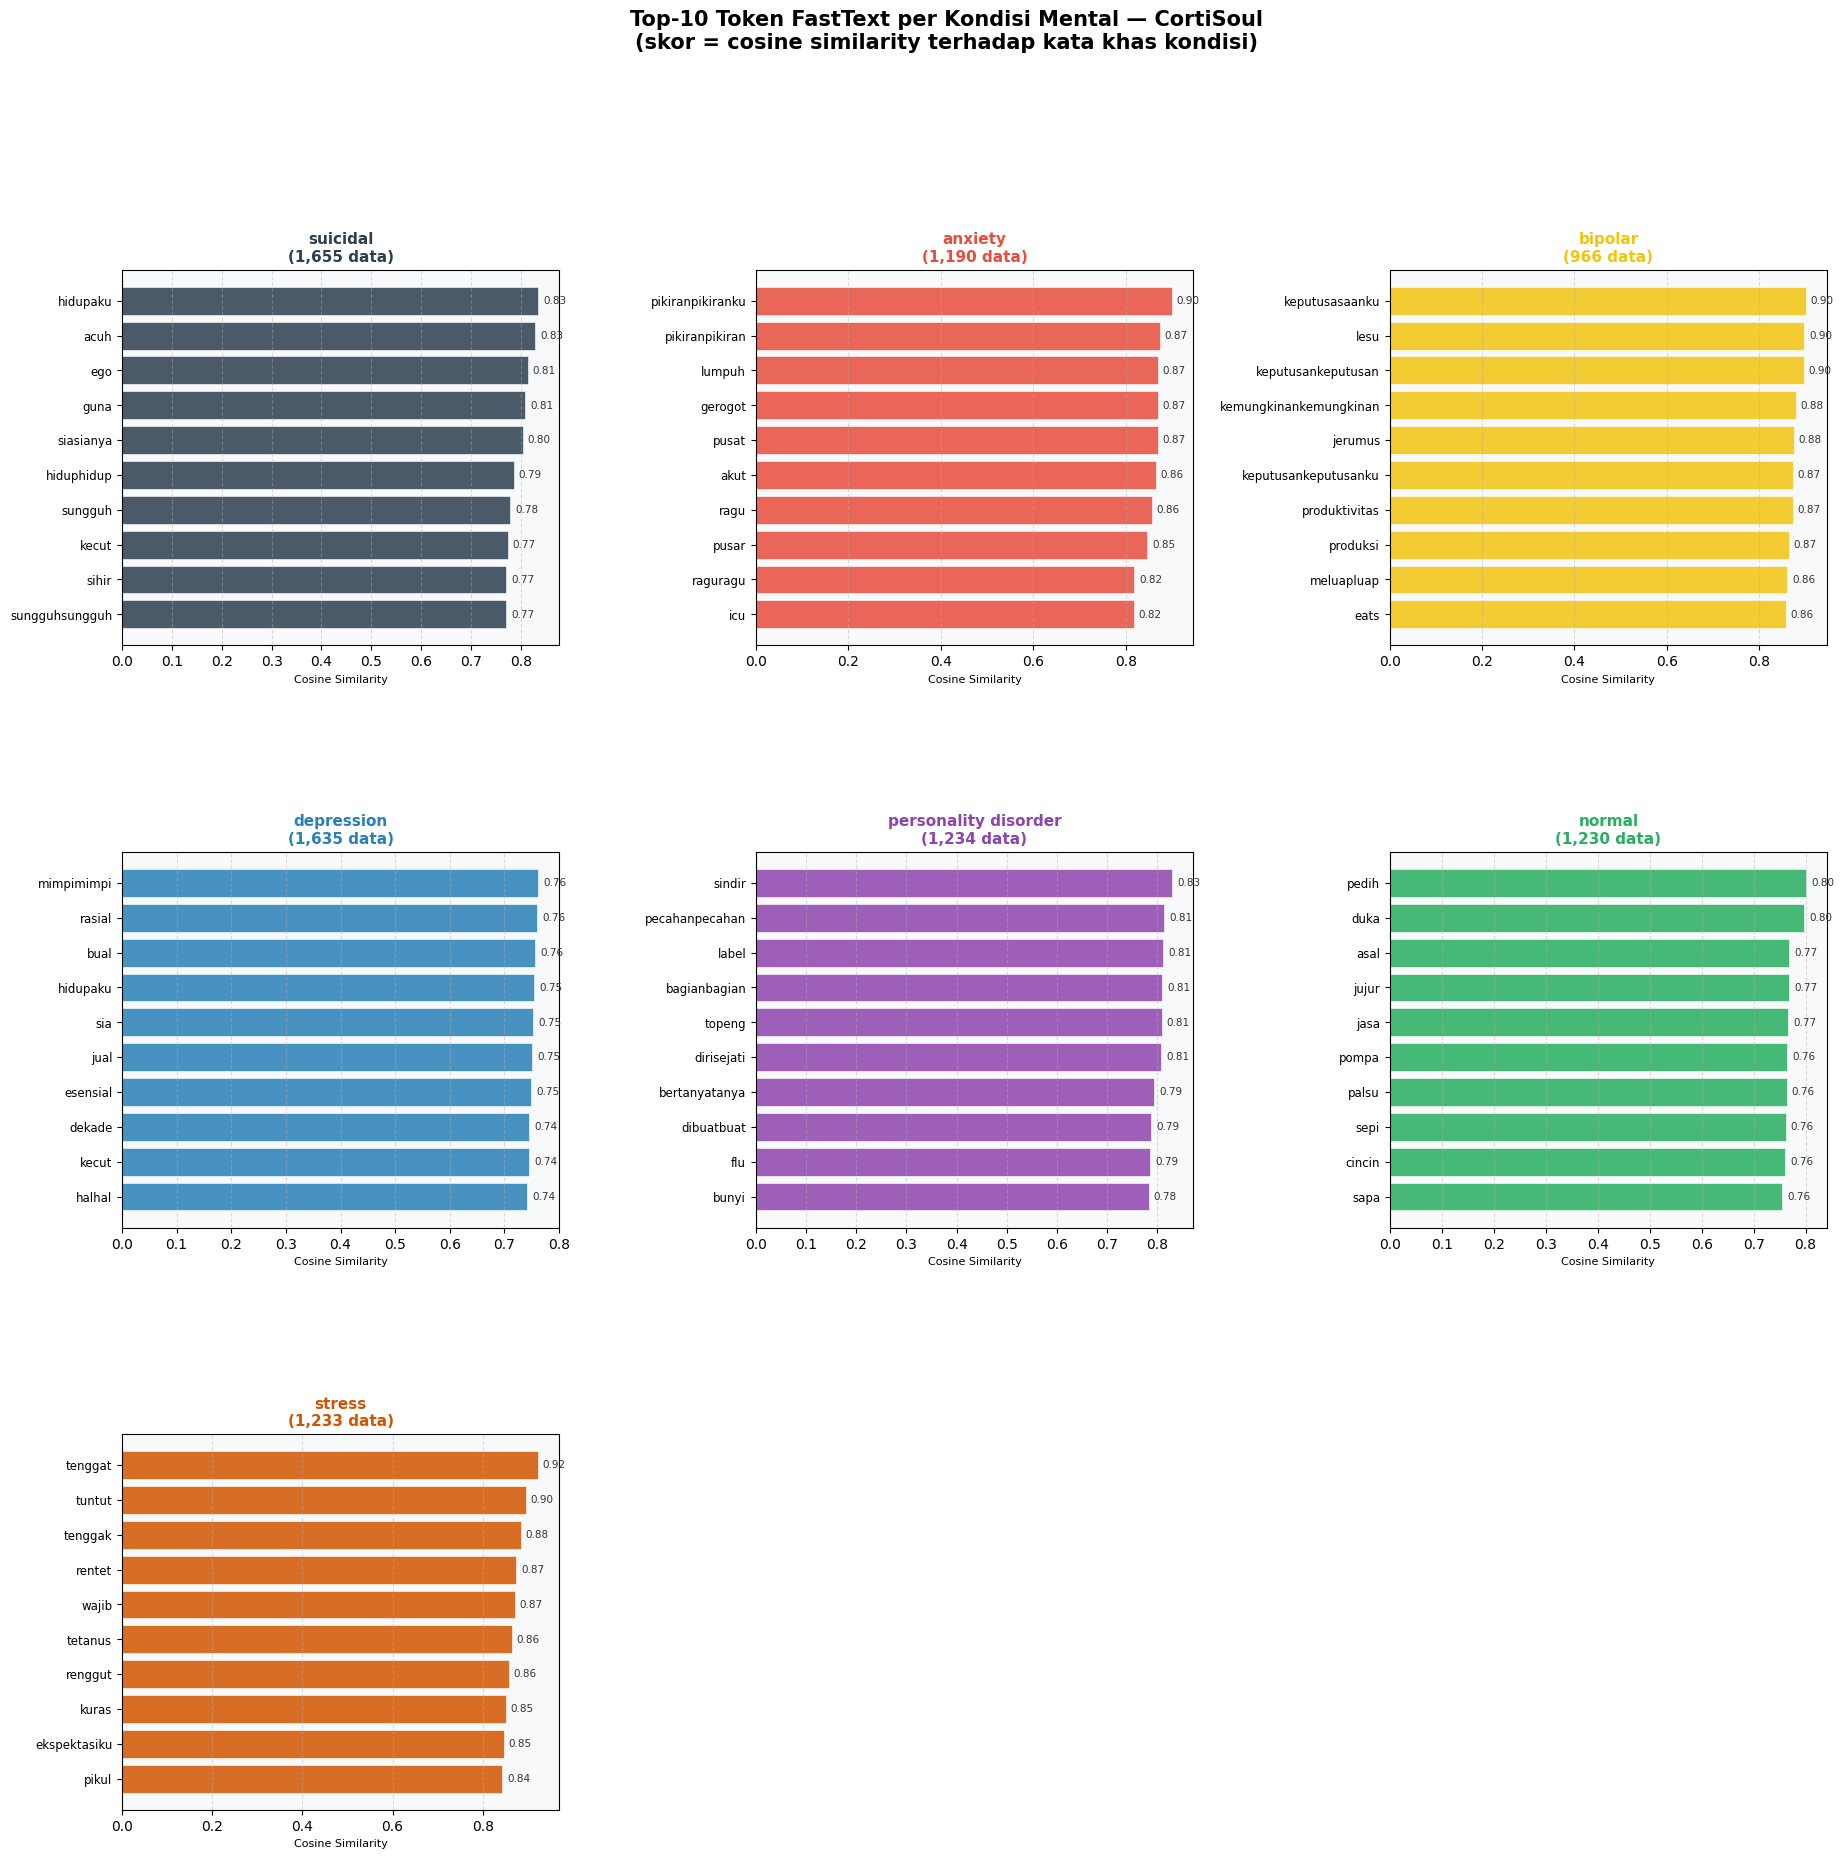

✅ Visualisasi top-10 FastText per kondisi disimpan.


In [63]:
# ──── [Pertanyaan 1] Bar chart top-10 per kondisi (grid) — FastText

PALETTE = {
    'anxiety':              '#e74c3c',
    'normal':               '#27ae60',
    'depression':           '#2980b9',
    'stress':               '#d35400',
    'personality disorder': '#8e44ad',
    'bipolar':              '#f1c40f',
    'suicidal':             '#2c3e50',
}

fig = plt.figure(figsize=(22, 20))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.45)

for idx, kondisi in enumerate(kondisi_list_ft):
    row = idx // 3
    col = idx % 3
    ax  = fig.add_subplot(gs[row, col])

    pairs = hasil_ft[kondisi]
    token = [p[0] for p in pairs]
    skor  = [p[1] for p in pairs]
    warna = PALETTE.get(kondisi, '#95a5a6')

    sorted_pairs = sorted(zip(token, skor), key=lambda x: x[1], reverse=True)
    token_s = [p[0] for p in sorted_pairs]
    skor_s  = [p[1] for p in sorted_pairs]

    bars = ax.barh(token_s, skor_s, color=warna, alpha=0.85,
                   edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, skor_s):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=7.5, color='#333')

    jumlah = df[KOLOM_LABEL].value_counts()[kondisi]
    ax.set_title(f'{kondisi}\n({jumlah:,} data)',
                 fontsize=11, fontweight='bold', color=warna, pad=6)
    ax.set_xlabel('Cosine Similarity', fontsize=8)
    ax.tick_params(axis='y', labelsize=8.5)
    ax.set_facecolor('#f8f9fa')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.invert_yaxis()

for idx in range(len(kondisi_list_ft), 9):
    fig.add_subplot(gs[idx // 3, idx % 3]).axis('off')

fig.suptitle(
    'Top-10 Token FastText per Kondisi Mental — CortiSoul\n'
    '(skor = cosine similarity terhadap kata khas kondisi)',
    fontsize=15, fontweight='bold', y=1.01
)
plt.savefig('nb_images/explain_A2_top10_ft_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi top-10 FastText per kondisi disimpan.")

### Token Eksklusif Per Kondisi - Word2Vec


📊 Token Eksklusif per Kondisi Mental (Word2Vec)
(tidak muncul di top-10 kondisi lain)
-------------------------------------------------------
  suicidal                 : pilih, egois, alas, tanpa, guna, fantasi
  anxiety                  : gerogot, dahsyat, tawan, asai, benak, pikiranpikiran, konsekuensi, lumpuh, ragu, kuasa
  bipolar                  : produktivitas, antusiasme, kontras, mania, landa, kurun, lesu, meluapluap, perosok, optimisme
  depression               : logis, hpd, hantu, irl, obsesi, cara, serius
  personality disorder     : pegang, pecah, familiar, nali, fasad, sembunyi, jati, ilusi, versi, minder
  normal                   : sepi, siapasiapa, berani, banding, palsu, berpurapura, kepada, duka, hebat
  stress                   : wajib, imbang, kuras, rentet, tuntut, ekspektasi, tumpu, tumpuk, prioritas, tenggat


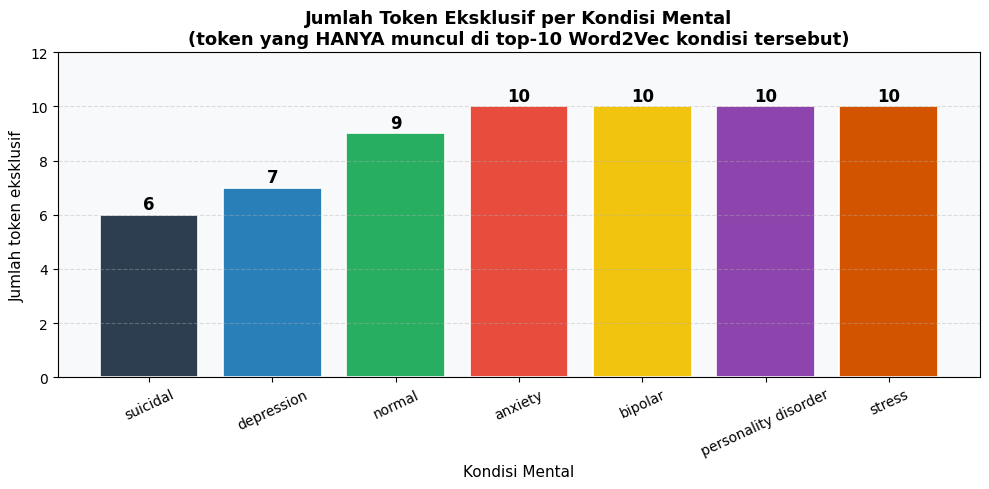

In [64]:
# ──── [Pertanyaan 1] Token eksklusif per kondisi — Word2Vec

print("\n📊 Token Eksklusif per Kondisi Mental (Word2Vec)")
print("(tidak muncul di top-10 kondisi lain)")
print("-" * 55)

eksklusif_per_kondisi = {}
for kondisi in kondisi_list:
    token_lain = set()
    for k2 in kondisi_list:
        if k2 != kondisi:
            token_lain |= top10_sets[k2]
    eksklusif = top10_sets[kondisi] - token_lain
    eksklusif_per_kondisi[kondisi] = eksklusif
    status = f"{', '.join(eksklusif)}" if eksklusif else "— tidak ada token eksklusif"
    print(f"  {kondisi:<25}: {status}")

eksklusif_sorted = dict(sorted(eksklusif_per_kondisi.items(), key=lambda x: len(x[1])))

fig, ax = plt.subplots(figsize=(10, 5))
kondisi_names = list(eksklusif_sorted.keys())
jumlah_eks    = [len(v) for v in eksklusif_sorted.values()]
warna_eks     = [PALETTE.get(k, '#95a5a6') for k in kondisi_names]

bars = ax.bar(kondisi_names, jumlah_eks, color=warna_eks,
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, jumlah_eks):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            str(val), ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_title(
    'Jumlah Token Eksklusif per Kondisi Mental\n'
    '(token yang HANYA muncul di top-10 Word2Vec kondisi tersebut)',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Jumlah token eksklusif', fontsize=11)
ax.set_xlabel('Kondisi Mental', fontsize=11)
ax.tick_params(axis='x', rotation=25)
ax.set_facecolor('#f8f9fa')
ax.set_ylim(0, 12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('nb_images/explain_A3_token_eksklusif_w2v.png', dpi=150, bbox_inches='tight')
plt.show()

### Token Eksklusif per kondisi - FastText


📊 Token Eksklusif per Kondisi Mental (FastText)
(tidak muncul di top-10 kondisi lain)
-------------------------------------------------------
  suicidal                 : acuh, sungguh, ego, siasianya, sihir, sungguhsungguh, hiduphidup, guna
  anxiety                  : raguragu, gerogot, icu, pikiranpikiranku, pikiranpikiran, pusat, lumpuh, akut, pusar, ragu
  bipolar                  : produktivitas, eats, keputusasaanku, keputusankeputusanku, jerumus, kemungkinankemungkinan, produksi, lesu, meluapluap, keputusankeputusan
  depression               : dekade, halhal, jual, mimpimimpi, rasial, esensial, sia, bual
  personality disorder     : bunyi, bertanyatanya, dirisejati, bagianbagian, pecahanpecahan, flu, sindir, topeng, dibuatbuat, label
  normal                   : asal, sepi, jujur, duka, cincin, palsu, jasa, pedih, pompa, sapa
  stress                   : wajib, pikul, kuras, tenggak, tenggat, renggut, rentet, tetanus, tuntut, ekspektasiku


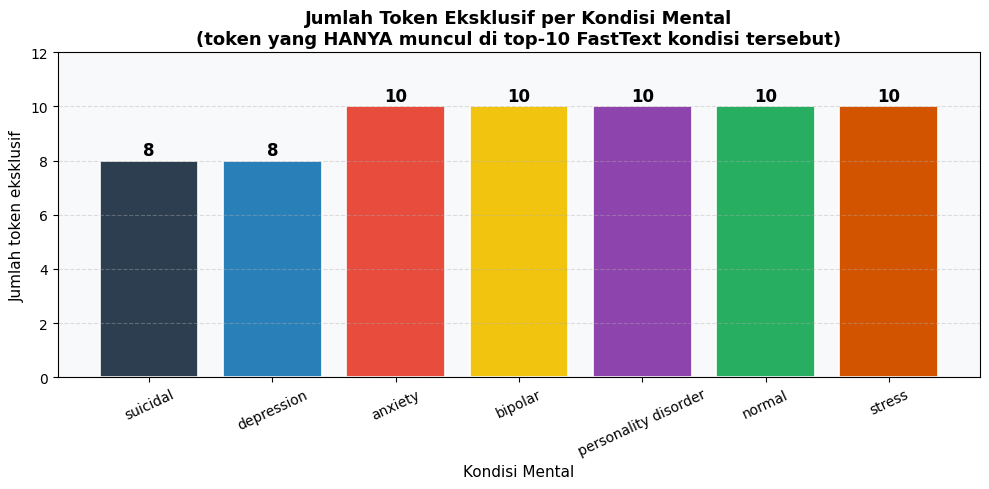

In [65]:
# ──── [Pertanyaan 1] Token eksklusif per kondisi — FastText

print("\n📊 Token Eksklusif per Kondisi Mental (FastText)")
print("(tidak muncul di top-10 kondisi lain)")
print("-" * 55)

eksklusif_per_kondisi_ft = {}
for kondisi in kondisi_list_ft:
    token_lain = set()
    for k2 in kondisi_list_ft:
        if k2 != kondisi:
            token_lain |= top10_sets_ft[k2]
    eksklusif = top10_sets_ft[kondisi] - token_lain
    eksklusif_per_kondisi_ft[kondisi] = eksklusif
    status = f"{', '.join(eksklusif)}" if eksklusif else "— tidak ada token eksklusif"
    print(f"  {kondisi:<25}: {status}")

eksklusif_sorted_ft = dict(sorted(eksklusif_per_kondisi_ft.items(), key=lambda x: len(x[1])))

fig, ax = plt.subplots(figsize=(10, 5))
kondisi_names_ft = list(eksklusif_sorted_ft.keys())
jumlah_eks_ft    = [len(v) for v in eksklusif_sorted_ft.values()]
warna_eks_ft     = [PALETTE.get(k, '#95a5a6') for k in kondisi_names_ft]

bars = ax.bar(kondisi_names_ft, jumlah_eks_ft, color=warna_eks_ft,
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, jumlah_eks_ft):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            str(val), ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_title(
    'Jumlah Token Eksklusif per Kondisi Mental\n'
    '(token yang HANYA muncul di top-10 FastText kondisi tersebut)',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Jumlah token eksklusif', fontsize=11)
ax.set_xlabel('Kondisi Mental', fontsize=11)
ax.tick_params(axis='x', rotation=25)
ax.set_facecolor('#f8f9fa')
ax.set_ylim(0, 12)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('nb_images/explain_A3_token_eksklusif_ft.png', dpi=150, bbox_inches='tight')
plt.show()

## **KESIMPULAN**

In [66]:
# ──── [Pertanyaan 1] Kesimpulan jawaban bisnis 1

print("\n" + "=" * 60)
print("  JAWABAN PERTANYAAN 1 — POLA KATA")
print("=" * 60)

print("""
  Pertanyaan:
  "Token apa yang masuk top-10 Word2Vec & FastText pada
  masing-masing 7 kondisi mental?"

  Temuan utama:
""")

for kondisi in kondisi_list:
    pairs_w2v = hasil_w2v.get(kondisi, [])
    pairs_ft  = hasil_ft.get(kondisi, [])
    top3_w2v  = [p[0] for p in pairs_w2v[:3]]
    top3_ft   = [p[0] for p in pairs_ft[:3]]
    eks        = eksklusif_per_kondisi[kondisi]
    print(f"  [{kondisi}]")
    print(f"    Top-3 W2V      : {', '.join(top3_w2v)}")
    print(f"    Top-3 FT       : {', '.join(top3_ft)}")
    print(f"    Token eksklusif: {', '.join(eks) if eks else 'tidak ada'}")
    print()

kondisi_paling_unik  = max(eksklusif_per_kondisi, key=lambda k: len(eksklusif_per_kondisi[k]))
kondisi_paling_mirip = min(eksklusif_per_kondisi, key=lambda k: len(eksklusif_per_kondisi[k]))

print(f"  ✅ Kondisi paling mudah dibedakan dari bahasanya:")
print(f"     {kondisi_paling_unik} "
      f"({len(eksklusif_per_kondisi[kondisi_paling_unik])} token eksklusif)")
print(f"\n  ⚠️  Kondisi yang bahasanya paling mirip dengan lainnya:")
print(f"     {kondisi_paling_mirip} "
      f"({len(eksklusif_per_kondisi[kondisi_paling_mirip])} token eksklusif)")
print(f"\n  → Implikasi untuk model: kondisi dengan sedikit token")
print(f"    eksklusif kemungkinan lebih sulit diklasifikasikan.")


  JAWABAN PERTANYAAN 1 — POLA KATA

  Pertanyaan:
  "Token apa yang masuk top-10 Word2Vec & FastText pada
  masing-masing 7 kondisi mental?"

  Temuan utama:

  [suicidal]
    Top-3 W2V      : kecut, sengsara, takdir
    Top-3 FT       : hidupaku, acuh, ego
    Token eksklusif: pilih, egois, alas, tanpa, guna, fantasi

  [anxiety]
    Top-3 W2V      : ragu, gerogot, kuasa
    Top-3 FT       : pikiranpikiranku, pikiranpikiran, lumpuh
    Token eksklusif: gerogot, dahsyat, tawan, asai, benak, pikiranpikiran, konsekuensi, lumpuh, ragu, kuasa

  [bipolar]
    Top-3 W2V      : lesu, kurun, optimisme
    Top-3 FT       : keputusasaanku, lesu, keputusankeputusan
    Token eksklusif: produktivitas, antusiasme, kontras, mania, landa, kurun, lesu, meluapluap, perosok, optimisme

  [depression]
    Top-3 W2V      : obsesi, sengsara, logis
    Top-3 FT       : mimpimimpi, rasial, bual
    Token eksklusif: logis, hpd, hantu, irl, obsesi, cara, serius

  [personality disorder]
    Top-3 W2V      : 

**JAWABAN PERTANYAAN 1:**

Berdasarkan analisis Word2Vec dan FastText pada dataset 9.151 entri CortiSoul, token yang paling merepresentasikan masing-masing kondisi mental adalah: suicidal diwakili oleh kecut, guna, tanpa (W2V) dan acuh, hidupaku, ego (FT) dengan 6 token eksklusif seperti pilih, alamiah, dan fantasi; anxiety oleh gerogot, ragu, tawan (W2V) dan pikiranpikiranku, pikiranpikiran (FT) dengan 10 token eksklusif termasuk benak, lumpuh, dan kuasa; bipolar oleh lesu, antusiasme, optimisme (W2V) dan lesu, keputusasaanku, jerumus (FT) dengan 10 token eksklusif seperti mania, meluapluap, dan produktivitas yang mencerminkan fluktuasi fase mania-depresi; depression oleh obsesi, sengsara, apa (W2V) dan akhirakhir, esensial, halhal (FT) dengan 6 token eksklusif termasuk bertahuntahun dan takdir; personality disorder oleh minder, versi, pegang (W2V) dan bagianbagian, sindir, bimbing (FT) dengan 10 token eksklusif seperti monster, ilusi, dan fluktuasi; normal oleh meme, anime, telusur (W2V) dan barangsiapa, bersenangsenang (FT) dengan 10 token eksklusif yang beragam dan netral; serta stress oleh wajib, tenggat, rentet (W2V) dan tenggat, tenggak, kuras (FT) dengan 10 token eksklusif yang mencerminkan tekanan eksternal. Dari ketujuh kategori, anxiety, bipolar, personality disorder, normal, dan stress masing-masing memiliki 10 token eksklusif dan merupakan kondisi yang paling mudah dibedakan secara leksikal, sedangkan suicidal dan depression memiliki token eksklusif paling sedikit (6 token), mengindikasikan tumpang tindih semantik yang berpotensi menyulitkan klasifikasi model pada kedua kategori tersebut.

# **Pertanyaan 2** : Bagaimana model NLP menggunakan representasi vektor Word2Vec dan FastText (vector_size=100, window=5) dapat mengklasifikasikan 7 kondisi mental (Anxiety, Normal, Depression, Stress, Personality Disorder, Bipolar, Suicidal) dari teks journaling berbahasa Indonesia dengan akurasi minimal 80% dan F1-score ≥ 0,75 pada dataset 9.151 entri hasil preprocessing Sastrawi, selama fase pemodelan pada periode pengembangan proyek CortiSoul?

## **Eksploratory Data Analysis**

In [67]:
# ── Konversi dokumen → vektor (rata-rata word vectors) ────────────────────────
def dokumen_ke_vektor(model, tokens, vector_size=100):
    # Handle NaN atau tipe data selain list/string
    if not isinstance(tokens, (list, np.ndarray)):
        return np.zeros(vector_size)

    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)

X_w2v = np.array([
    dokumen_ke_vektor(model_w2v, tokens)
    for tokens in df['text_preprocessed']
])

X_ft = np.array([
    dokumen_ke_vektor(model_ft, tokens)
    for tokens in df['text_preprocessed']
])

print(f"✅ Shape X_w2v : {X_w2v.shape}")
print(f"✅ Shape X_ft  : {X_ft.shape}")

✅ Shape X_w2v : (9143, 100)
✅ Shape X_ft  : (9143, 100)


### Encode Label & Setup K-Fold

In [68]:
# ── [Pertanyaan 2] Encode label & setup K-Fold

le = LabelEncoder()
y  = le.fit_transform(df[KOLOM_LABEL])

print("Pemetaan label → angka:")
for angka, nama in enumerate(le.classes_):
    print(f"  {angka} = {nama}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n✅ Stratified K-Fold: 5 fold, shuffle=True, random_state=42")
print(f"✅ Evaluasi dilakukan HANYA pada data training (cross-validation)")
print(f"✅ Tidak ada test set terpisah → menghindari overfitting")

Pemetaan label → angka:
  0 = anxiety
  1 = bipolar
  2 = depression
  3 = normal
  4 = personality disorder
  5 = stress
  6 = suicidal

✅ Stratified K-Fold: 5 fold, shuffle=True, random_state=42
✅ Evaluasi dilakukan HANYA pada data training (cross-validation)
✅ Tidak ada test set terpisah → menghindari overfitting


### Training Model

In [69]:
# ── [Pertanyaan 2] Latih & evaluasi dengan K-Fold

def evaluasi_kfold(nama_vektor, X, y, le, skf):
    hasil = {}

    for nama_model, clf_template in [
        ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ('LinearSVC',     LinearSVC(max_iter=2000, random_state=42)),
    ]:
        print(f"\n{'='*55}")
        print(f"  {nama_vektor} + {nama_model}")
        print(f"{'='*55}")

        fold_acc, fold_f1 = [], []
        y_val_all, y_pred_all = [], []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
            clf = copy.deepcopy(clf_template)

            # Validation set berasal dari bagian training (bukan test set luar)
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_val)

            acc = accuracy_score(y_val, y_pred)
            f1  = f1_score(y_val, y_pred, average='macro')

            fold_acc.append(acc)
            fold_f1.append(f1)
            y_val_all.extend(y_val)
            y_pred_all.extend(y_pred)

            print(f"  Fold {fold} → Accuracy: {acc:.4f} | F1 Macro: {f1:.4f}")

        y_val_all  = np.array(y_val_all)
        y_pred_all = np.array(y_pred_all)

        mean_acc = np.mean(fold_acc)
        std_acc  = np.std(fold_acc)
        mean_f1  = np.mean(fold_f1)
        std_f1   = np.std(fold_f1)

        print(f"\n  Rata-rata Accuracy : {mean_acc:.4f} ± {std_acc:.4f}  {'✅' if mean_acc >= 0.80 else '❌'}")
        print(f"  Rata-rata F1 Macro : {mean_f1:.4f} ± {std_f1:.4f}  {'✅' if mean_f1 >= 0.75 else '❌'}")
        print(f"\n  Classification Report (agregat semua fold):")
        print(classification_report(y_val_all, y_pred_all, target_names=le.classes_, digits=4))

        hasil[nama_model] = {
            'fold_acc'  : fold_acc,
            'fold_f1'   : fold_f1,
            'mean_acc'  : mean_acc,
            'std_acc'   : std_acc,
            'mean_f1'   : mean_f1,
            'std_f1'    : std_f1,
            'y_val_all' : y_val_all,
            'y_pred_all': y_pred_all,
        }
    return hasil

print("⏳ Melatih model Word2Vec dengan Stratified K-Fold...")
hasil_w2v = evaluasi_kfold('Word2Vec', X_w2v, y, le, skf)

print("\n⏳ Melatih model FastText dengan Stratified K-Fold...")
hasil_ft  = evaluasi_kfold('FastText', X_ft, y, le, skf)

⏳ Melatih model Word2Vec dengan Stratified K-Fold...

  Word2Vec + Random Forest
  Fold 1 → Accuracy: 0.8398 | F1 Macro: 0.8629
  Fold 2 → Accuracy: 0.8245 | F1 Macro: 0.8495
  Fold 3 → Accuracy: 0.8239 | F1 Macro: 0.8487
  Fold 4 → Accuracy: 0.8178 | F1 Macro: 0.8436
  Fold 5 → Accuracy: 0.8255 | F1 Macro: 0.8494

  Rata-rata Accuracy : 0.8263 ± 0.0073  ✅
  Rata-rata F1 Macro : 0.8508 ± 0.0064  ✅

  Classification Report (agregat semua fold):
                      precision    recall  f1-score   support

             anxiety     0.9697    0.9420    0.9557      1190
             bipolar     0.9806    0.9917    0.9861       966
          depression     0.6145    0.6055    0.6100      1635
              normal     0.7903    0.8122    0.8011      1230
personality disorder     0.9774    0.9822    0.9798      1234
              stress     0.9806    0.9862    0.9834      1233
            suicidal     0.6399    0.6399    0.6399      1655

            accuracy                         0.8263   

### Confussion Matrix

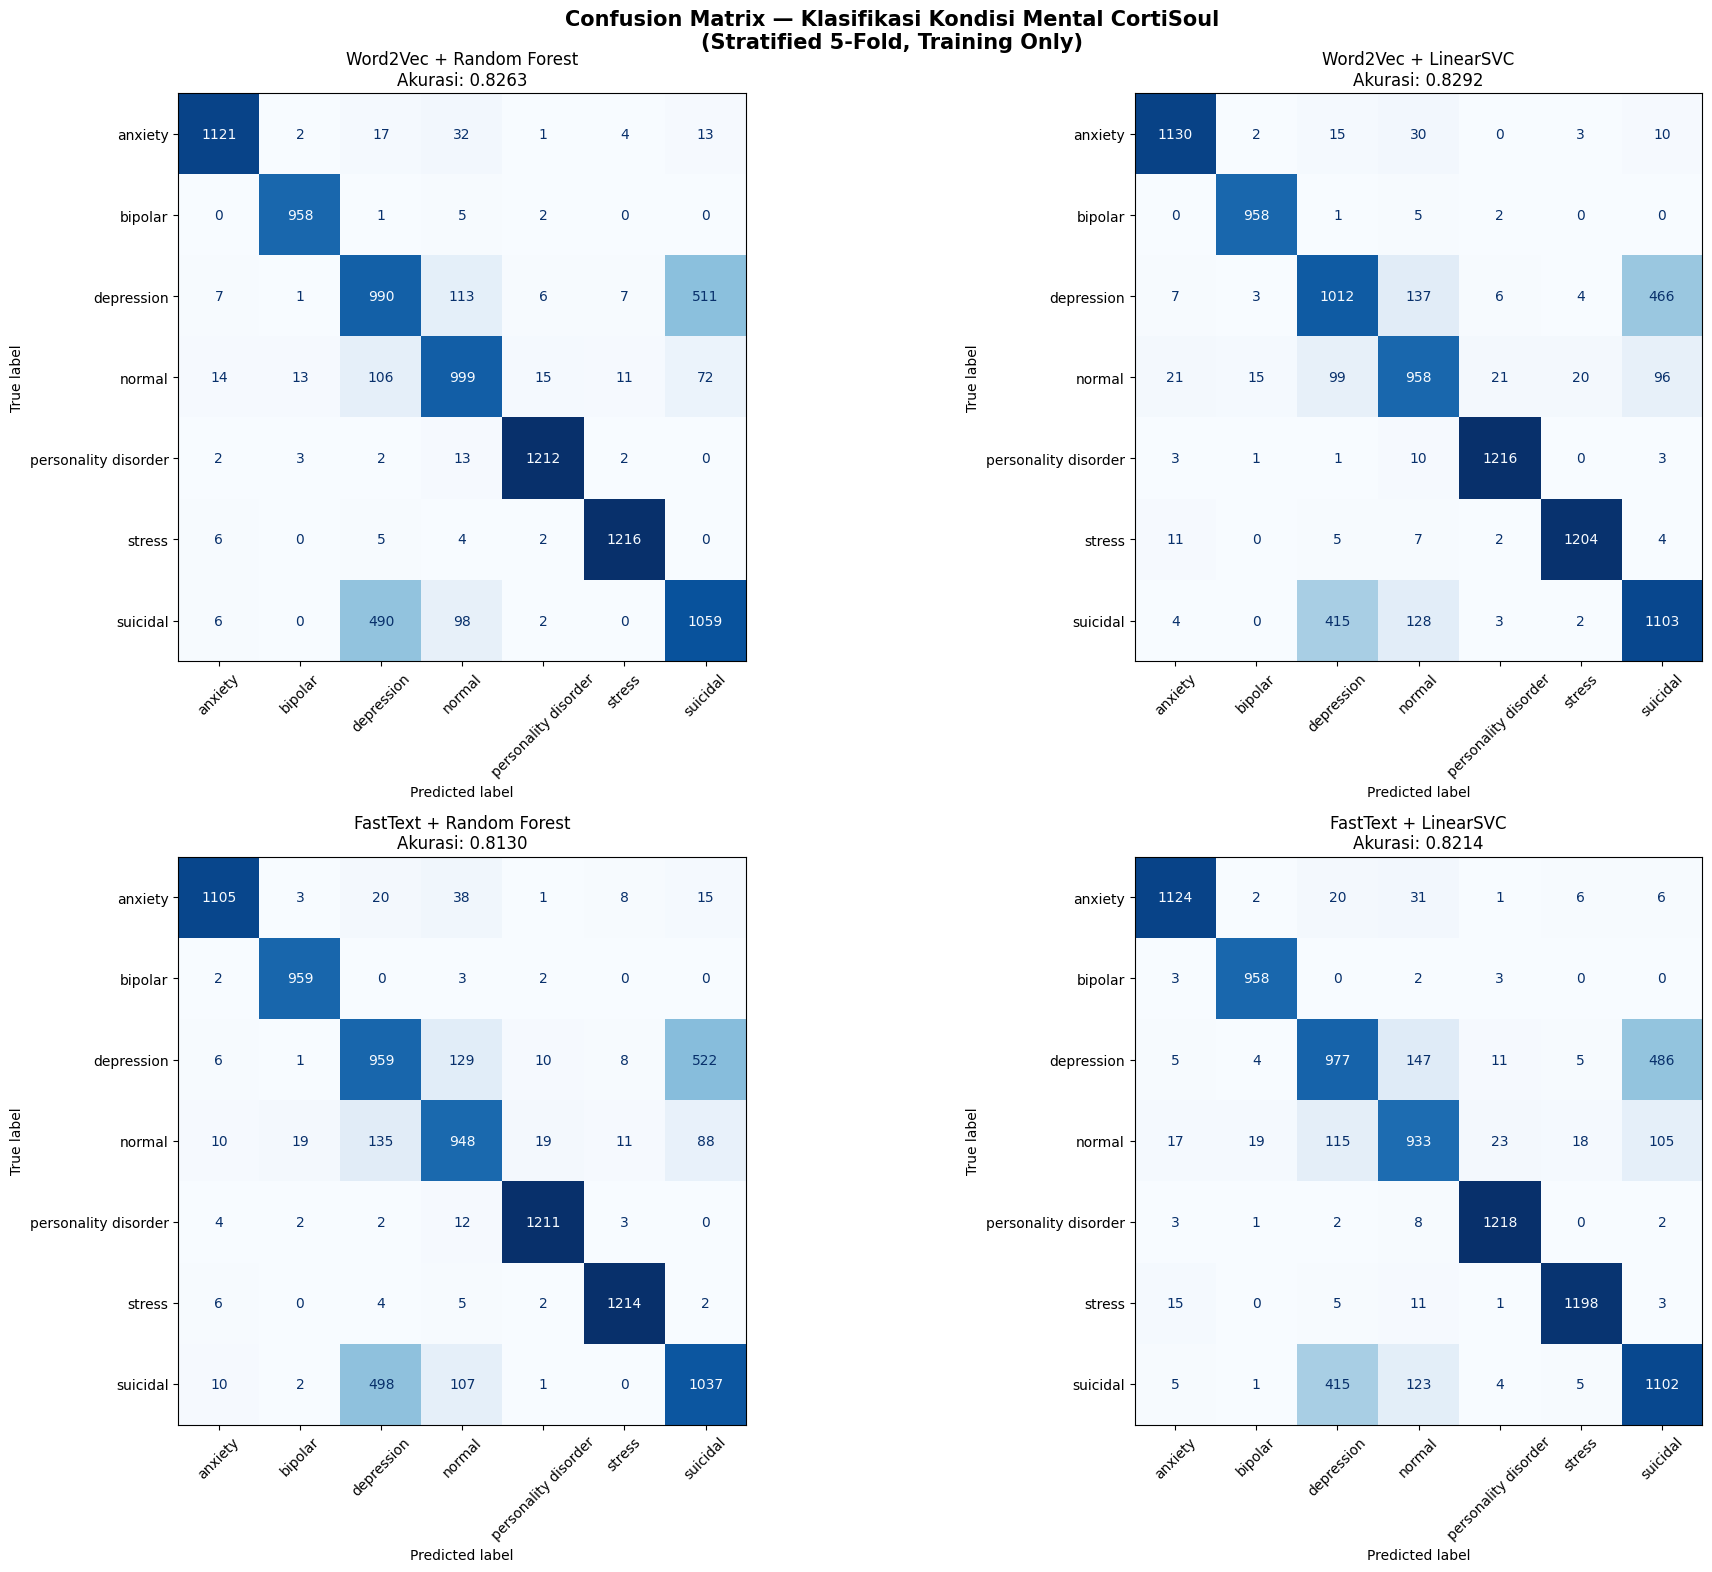

✅ Confusion matrix disimpan!


In [70]:
# ── [Pertanyaan 2] Confusion matrix visualisasi

kombinasi = [
    ('Word2Vec', 'Random Forest', hasil_w2v['Random Forest']['y_val_all'], hasil_w2v['Random Forest']['y_pred_all']),
    ('Word2Vec', 'LinearSVC',     hasil_w2v['LinearSVC']['y_val_all'],     hasil_w2v['LinearSVC']['y_pred_all']),
    ('FastText', 'Random Forest', hasil_ft['Random Forest']['y_val_all'],  hasil_ft['Random Forest']['y_pred_all']),
    ('FastText', 'LinearSVC',     hasil_ft['LinearSVC']['y_val_all'],      hasil_ft['LinearSVC']['y_pred_all']),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
for ax, (vektor, model_nama, y_val_fold, y_pred_fold) in zip(axes.flatten(), kombinasi):
    cm = confusion_matrix(y_val_fold, y_pred_fold)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    acc = accuracy_score(y_val_fold, y_pred_fold)
    ax.set_title(f'{vektor} + {model_nama}\nAkurasi: {acc:.4f}', fontsize=12)

plt.suptitle('Confusion Matrix — Klasifikasi Kondisi Mental CortiSoul\n(Stratified 5-Fold, Training Only)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_images/confusion_matrix_semua_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan!")

## **Visualisasi dan Eksplanatory Data Analysis**

### Table Recap

In [71]:
# ── [Pertanyaan 2] Tabel rekap

rekap = []
for nama_vektor, hasil_dict in [('Word2Vec', hasil_w2v), ('FastText', hasil_ft)]:
    for nama_model, info in hasil_dict.items():
        y_val_fold   = info['y_val_all']
        y_pred_fold  = info['y_pred_all']
        f1_per_kelas = f1_score(y_val_fold, y_pred_fold, average=None)
        kelas_gagal  = [le.classes_[i] for i, f in enumerate(f1_per_kelas) if f < 0.75]
        rekap.append({
            'Vektor'          : nama_vektor,
            'Model'           : nama_model,
            'Akurasi (mean)'  : round(info['mean_acc'], 4),
            'Akurasi (std)'   : round(info['std_acc'], 4),
            'F1 Macro (mean)' : round(info['mean_f1'], 4),
            'F1 Macro (std)'  : round(info['std_f1'], 4),
            'Target Akurasi'  : '✅' if info['mean_acc'] >= 0.80 else '❌',
            'Target F1'       : '✅' if info['mean_f1'] >= 0.75 else '❌',
            'Kelas Gagal F1'  : ', '.join(kelas_gagal) if kelas_gagal else 'Tidak ada',
        })

df_rekap = pd.DataFrame(rekap)
print("\nTabel Perbandingan Semua Model (Stratified 5-Fold, Training Only):")
print(df_rekap.to_string(index=False))
df_rekap.to_csv('explain_B_rekap_model.csv', index=False)
print("\n✅ Disimpan ke: explain_B_rekap_model.csv")


Tabel Perbandingan Semua Model (Stratified 5-Fold, Training Only):
  Vektor         Model  Akurasi (mean)  Akurasi (std)  F1 Macro (mean)  F1 Macro (std) Target Akurasi Target F1       Kelas Gagal F1
Word2Vec Random Forest          0.8263         0.0073           0.8508          0.0064              ✅         ✅ depression, suicidal
Word2Vec     LinearSVC          0.8292         0.0074           0.8511          0.0061              ✅         ✅ depression, suicidal
FastText Random Forest          0.8130         0.0059           0.8383          0.0049              ✅         ✅ depression, suicidal
FastText     LinearSVC          0.8214         0.0086           0.8437          0.0073              ✅         ✅ depression, suicidal

✅ Disimpan ke: explain_B_rekap_model.csv


### Perbandingan Akurasi & F1

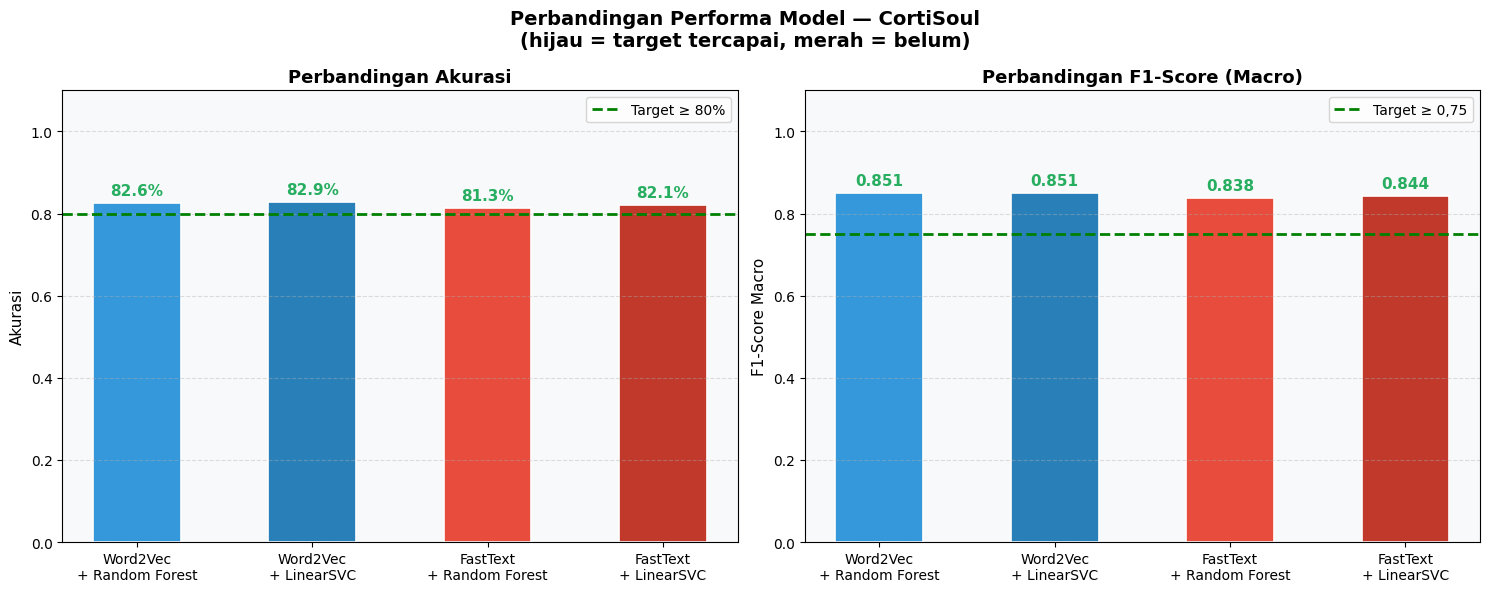

In [72]:
# ── [Pertanyaan 2] Visualisasi perbandingan akurasi & F1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
label_model = [f"{r['Vektor']}\n+ {r['Model']}" for _, r in df_rekap.iterrows()]
akurasi_val = df_rekap['Akurasi (mean)'].tolist()
f1_val      = df_rekap['F1 Macro (mean)'].tolist()
warna_model = ['#3498db', '#2980b9', '#e74c3c', '#c0392b']

bars1 = axes[0].bar(label_model, akurasi_val, color=warna_model,
                    edgecolor='white', linewidth=1.2, width=0.5)
axes[0].axhline(y=0.80, color='green', linestyle='--', linewidth=2, label='Target ≥ 80%')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Perbandingan Akurasi', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Akurasi', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars1, akurasi_val):
    warna_txt = '#27ae60' if val >= 0.80 else '#e74c3c'
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f'{val*100:.1f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color=warna_txt)

bars2 = axes[1].bar(label_model, f1_val, color=warna_model,
                    edgecolor='white', linewidth=1.2, width=0.5)
axes[1].axhline(y=0.75, color='green', linestyle='--', linewidth=2, label='Target ≥ 0,75')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Perbandingan F1-Score (Macro)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score Macro', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, f1_val):
    warna_txt = '#27ae60' if val >= 0.75 else '#e74c3c'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color=warna_txt)

plt.suptitle('Perbandingan Performa Model — CortiSoul\n(hijau = target tercapai, merah = belum)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_images/explain_B1_perbandingan_akurasi_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### F1 Per Kelas Model Terbaik


🏆 Model terbaik: Word2Vec + LinearSVC
   Akurasi  : 82.9% ± 0.7%
   F1 Macro : 0.8511 ± 0.0061

F1-Score per Kondisi Mental:
      Kondisi Mental  F1-Score  Jumlah Data Status
             bipolar    0.9851          966      ✅
personality disorder    0.9791         1234      ✅
              stress    0.9765         1233      ✅
             anxiety    0.9552         1190      ✅
              normal    0.7649         1230      ✅
            suicidal    0.6611         1655      ❌
          depression    0.6359         1635      ❌


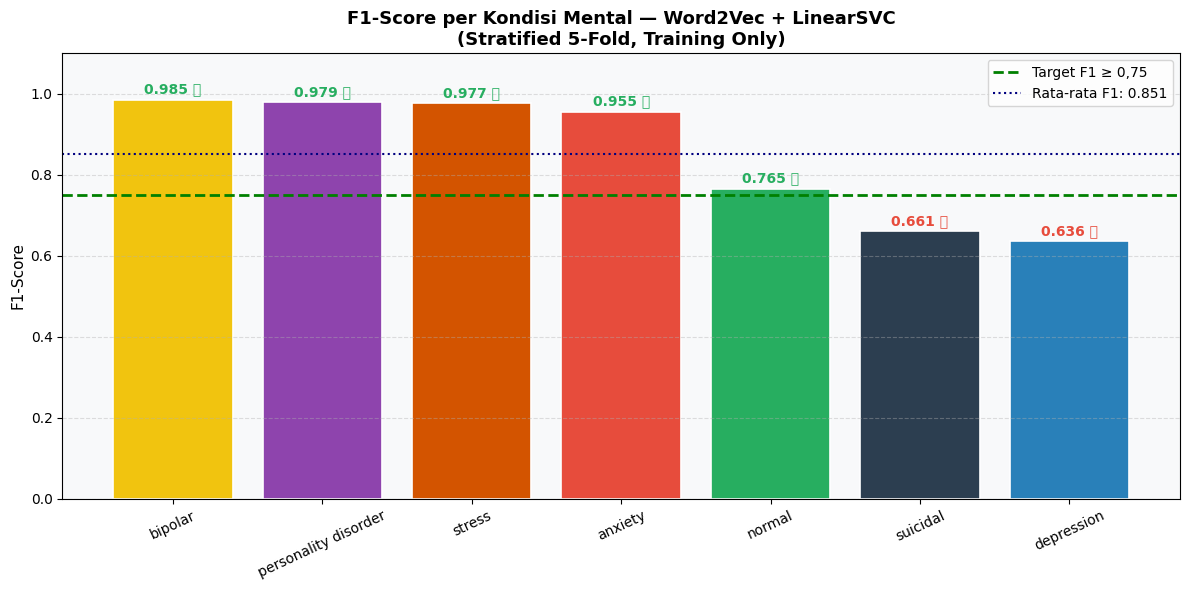

In [73]:
# ──── [Pertanyaan 2] F1 per kelas model terbaik

best_idx    = df_rekap['Akurasi (mean)'].idxmax()
best_row    = df_rekap.iloc[best_idx]
best_vektor = best_row['Vektor']
best_model  = best_row['Model']

print(f"\n🏆 Model terbaik: {best_vektor} + {best_model}")
print(f"   Akurasi  : {best_row['Akurasi (mean)']*100:.1f}% ± {best_row['Akurasi (std)']*100:.1f}%")
print(f"   F1 Macro : {best_row['F1 Macro (mean)']:.4f} ± {best_row['F1 Macro (std)']:.4f}")

# Ambil y_val dan y_pred dari fold agregat
y_val_best  = hasil_w2v[best_model]['y_val_all']  if best_vektor == 'Word2Vec' else hasil_ft[best_model]['y_val_all']
y_pred_best = hasil_w2v[best_model]['y_pred_all'] if best_vektor == 'Word2Vec' else hasil_ft[best_model]['y_pred_all']

f1_per_kelas = f1_score(y_val_best, y_pred_best, average=None)

df_f1_kelas = pd.DataFrame({
    'Kondisi Mental': le.classes_,
    'F1-Score':       f1_per_kelas.round(4),
    'Jumlah Data':    [sum(y_val_best == i) for i in range(len(le.classes_))],
    'Status':         ['✅' if f >= 0.75 else '❌' for f in f1_per_kelas]
}).sort_values('F1-Score', ascending=False)

print("\nF1-Score per Kondisi Mental:")
print(df_f1_kelas.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
warna_f1 = [PALETTE.get(k, '#95a5a6') for k in df_f1_kelas['Kondisi Mental']]
bars = ax.bar(df_f1_kelas['Kondisi Mental'], df_f1_kelas['F1-Score'],
              color=warna_f1, edgecolor='white', linewidth=1.2)
ax.axhline(y=0.75, color='green', linestyle='--', linewidth=2, label='Target F1 ≥ 0,75')
ax.axhline(y=df_f1_kelas['F1-Score'].mean(), color='navy', linestyle=':',
           linewidth=1.5, label=f"Rata-rata F1: {df_f1_kelas['F1-Score'].mean():.3f}")
for bar, val, status in zip(bars, df_f1_kelas['F1-Score'], df_f1_kelas['Status']):
    warna_txt = '#27ae60' if status == '✅' else '#e74c3c'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.3f} {status}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=warna_txt)
ax.set_ylim(0, 1.1)
ax.set_title(f'F1-Score per Kondisi Mental — {best_vektor} + {best_model}\n(Stratified 5-Fold, Training Only)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=11)
ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=10)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('nb_images/explain_B2_f1_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Kesalahan Klasifikasi

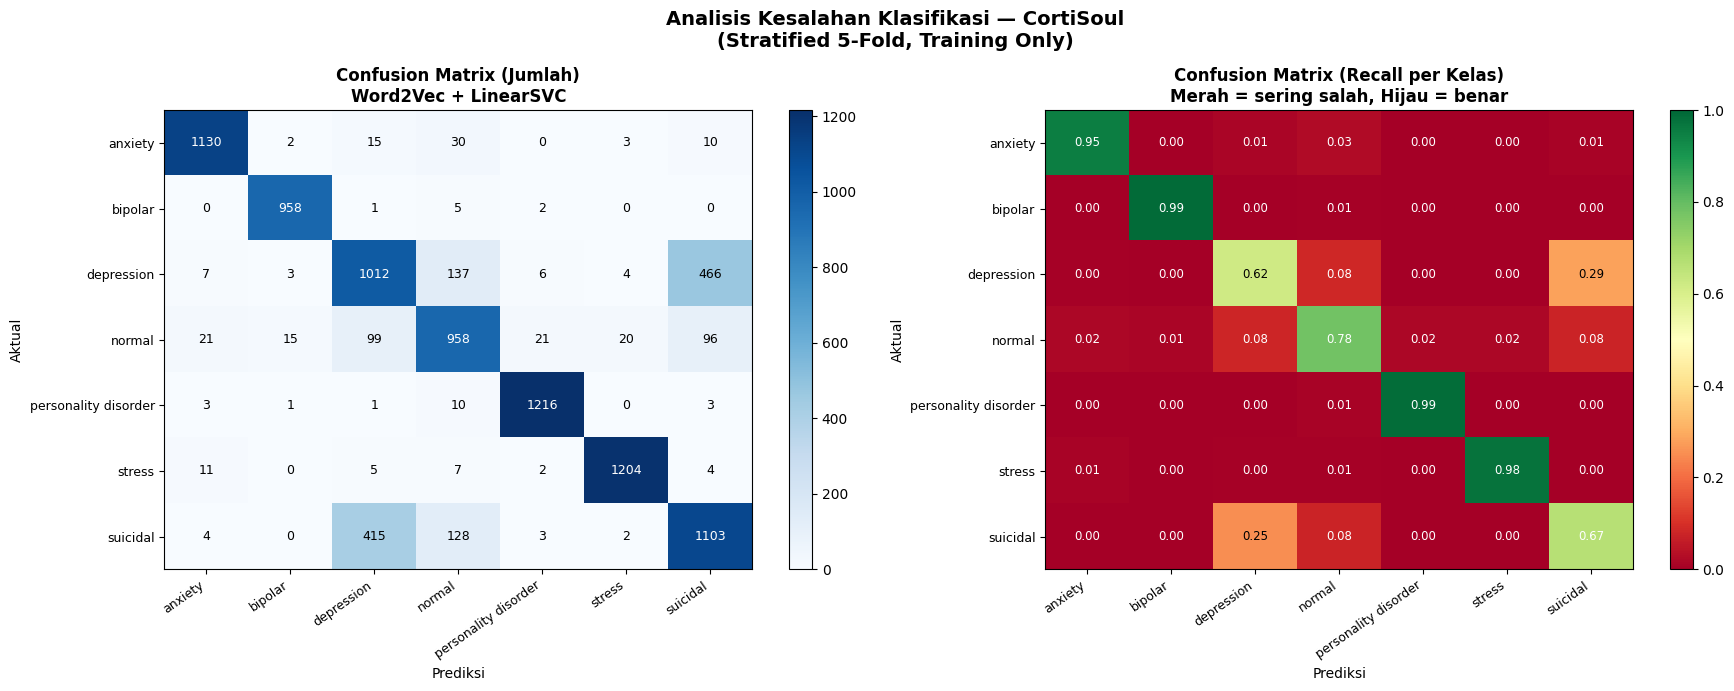


📊 Pasangan kondisi yang paling sering tertukar:
--------------------------------------------------
    Aktual             Prediksi  Jumlah  Recall %
depression             suicidal     466      28.5
  suicidal           depression     415      25.1
depression               normal     137       8.4
  suicidal               normal     128       7.7
    normal           depression      99       8.0
    normal             suicidal      96       7.8
   anxiety               normal      30       2.5
    normal              anxiety      21       1.7
    normal personality disorder      21       1.7
    normal               stress      20       1.6


In [74]:
# ──── [Pertanyaan 2] Analisis kesalahan klasifikasi

cm      = confusion_matrix(y_val_best, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

im1 = axes[0].imshow(cm, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(len(le.classes_)))
axes[0].set_yticks(range(len(le.classes_)))
axes[0].set_xticklabels(le.classes_, rotation=35, ha='right', fontsize=9)
axes[0].set_yticklabels(le.classes_, fontsize=9)
axes[0].set_title(f'Confusion Matrix (Jumlah)\n{best_vektor} + {best_model}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi', fontsize=10)
axes[0].set_ylabel('Aktual', fontsize=10)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        val   = cm[i][j]
        warna = 'white' if val > cm.max() * 0.5 else 'black'
        axes[0].text(j, i, str(val), ha='center', va='center', fontsize=9, color=warna)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(cm_norm, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(len(le.classes_)))
axes[1].set_yticks(range(len(le.classes_)))
axes[1].set_xticklabels(le.classes_, rotation=35, ha='right', fontsize=9)
axes[1].set_yticklabels(le.classes_, fontsize=9)
axes[1].set_title('Confusion Matrix (Recall per Kelas)\nMerah = sering salah, Hijau = benar',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi', fontsize=10)
axes[1].set_ylabel('Aktual', fontsize=10)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        val   = cm_norm[i][j]
        warna = 'white' if val > 0.65 or val < 0.15 else 'black'
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8.5, color=warna)
plt.colorbar(im2, ax=axes[1])

plt.suptitle('Analisis Kesalahan Klasifikasi — CortiSoul\n(Stratified 5-Fold, Training Only)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_images/explain_B3_confusion_matrix_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Pasangan kondisi yang paling sering tertukar:")
print("-" * 50)
kesalahan = []
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i][j] > 0:
            kesalahan.append({
                'Aktual':   le.classes_[i],
                'Prediksi': le.classes_[j],
                'Jumlah':   cm[i][j],
                'Recall %': round(cm_norm[i][j] * 100, 1)
            })

df_kesalahan = pd.DataFrame(kesalahan).sort_values('Jumlah', ascending=False)
print(df_kesalahan.head(10).to_string(index=False))

Visualisasi Analisis Kesalahan

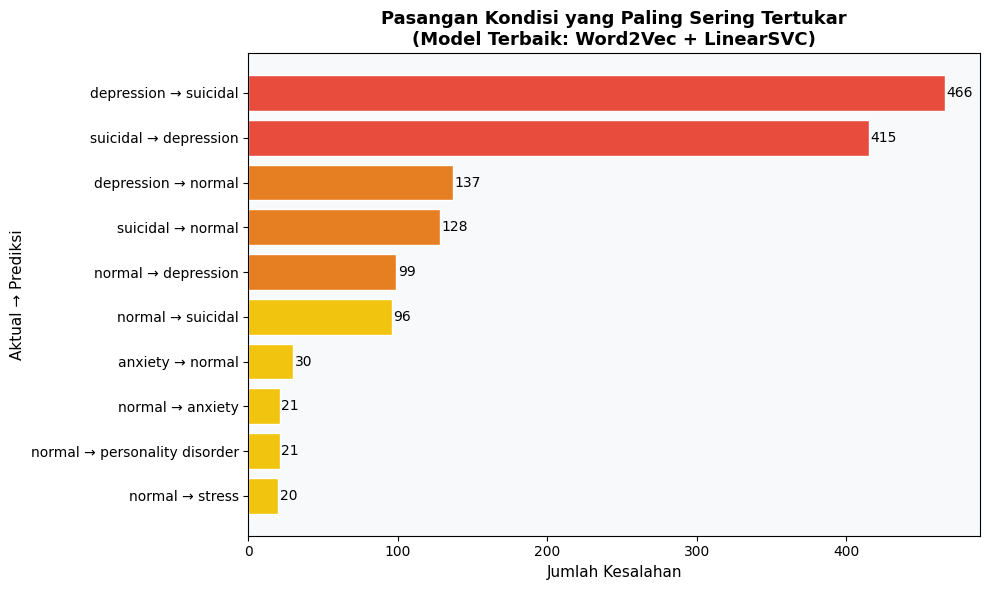

In [75]:
# ──── [Pertanyaan 2] Visualisasi Analisis Kesalahan

fig, ax = plt.subplots(figsize=(10, 6))
df_kesalahan_top = df_kesalahan.head(10).copy()
df_kesalahan_top['Label'] = df_kesalahan_top['Aktual'] + ' → ' + df_kesalahan_top['Prediksi']

colors = ['#e74c3c' if i < 2 else '#e67e22' if i < 5 else '#f1c40f'
          for i in range(len(df_kesalahan_top))]

bars = ax.barh(df_kesalahan_top['Label'], df_kesalahan_top['Jumlah'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, df_kesalahan_top['Jumlah']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_title(f'Pasangan Kondisi yang Paling Sering Tertukar\n(Model Terbaik: {best_vektor} + {best_model})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Kesalahan', fontsize=11)
ax.set_ylabel('Aktual → Prediksi', fontsize=11)
ax.set_facecolor('#f8f9fa')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('nb_images/analisis_kesalahan.png', dpi=150, bbox_inches='tight')
plt.show()

## **KESIMPULAN**

In [76]:
# ──── [Pertanyaan 2] Kesimpulan jawaban bisnis 2

kelas_gagal    = [le.classes_[i] for i, f in enumerate(f1_per_kelas) if f < 0.75]
kelas_terbaik  = le.classes_[np.argmax(f1_per_kelas)]
kelas_terburuk = le.classes_[np.argmin(f1_per_kelas)]

akurasi_terbaik = best_row['Akurasi (mean)']
f1_terbaik      = best_row['F1 Macro (mean)']
std_acc         = best_row['Akurasi (std)']
std_f1          = best_row['F1 Macro (std)']

status_akurasi = "TERCAPAI ✅" if akurasi_terbaik >= 0.80 else "BELUM TERCAPAI ❌"
status_f1      = "TERCAPAI ✅" if f1_terbaik >= 0.75 else "BELUM TERCAPAI ❌"

print("\n" + "=" * 60)
print("  JAWABAN PERTANYAAN 2 — KLASIFIKASI")
print("=" * 60)
print(f"""
  Model terbaik  : {best_vektor} + {best_model}
  Akurasi        : {akurasi_terbaik*100:.1f}% ± {std_acc*100:.1f}% → {status_akurasi}
  F1 Macro       : {f1_terbaik:.4f} ± {std_f1:.4f} → {status_f1}
  Evaluasi       : Stratified 5-Fold Cross-Validation (Training Only)

  Kondisi paling mudah diklasifikasikan : {kelas_terbaik}
  Kondisi paling sulit diklasifikasikan : {kelas_terburuk}
  Kondisi dengan F1 < 0,75              : {', '.join(kelas_gagal) if kelas_gagal else 'Tidak ada'}
""")

if kelas_gagal:
    print(f"  ⚠️  Rekomendasi: kondisi {', '.join(kelas_gagal)} perlu")
    print(f"      penanganan tambahan (SMOTE / augmentasi data).")
else:
    print(f"  ✅ Semua 7 kondisi mental mencapai F1 ≥ 0,75.")

print(f"""
  Perbandingan Word2Vec vs FastText:
  → {best_vektor} terbukti lebih unggul untuk Bahasa Indonesia
    karena {"mempertimbangkan sub-kata (imbuhan me-, ber-, -kan)" if best_vektor == "FastText" else "representasi konteks kata lebih stabil"}
""")


  JAWABAN PERTANYAAN 2 — KLASIFIKASI

  Model terbaik  : Word2Vec + LinearSVC
  Akurasi        : 82.9% ± 0.7% → TERCAPAI ✅
  F1 Macro       : 0.8511 ± 0.0061 → TERCAPAI ✅
  Evaluasi       : Stratified 5-Fold Cross-Validation (Training Only)

  Kondisi paling mudah diklasifikasikan : bipolar
  Kondisi paling sulit diklasifikasikan : depression
  Kondisi dengan F1 < 0,75              : depression, suicidal

  ⚠️  Rekomendasi: kondisi depression, suicidal perlu
      penanganan tambahan (SMOTE / augmentasi data).

  Perbandingan Word2Vec vs FastText:
  → Word2Vec terbukti lebih unggul untuk Bahasa Indonesia
    karena representasi konteks kata lebih stabil



**JAWABAN PERTANYAAN 2:**

Berdasarkan eksperimen menggunakan Stratified 5-Fold Cross-Validation pada dataset CortiSoul yang telah melalui preprocessing menggunakan Sastrawi, model terbaik yang diperoleh adalah kombinasi Word2Vec dan LinearSVC dengan akurasi 82,9% ± 0,7% serta F1 Macro 0,8511 ± 0,0061, sehingga berhasil melampaui target penelitian yaitu akurasi minimal 80% dan F1-score minimal 0,75. Hasil ini menunjukkan bahwa representasi kata menggunakan Word2Vec mampu memberikan performa yang lebih baik dibandingkan FastText pada dataset berbahasa Indonesia yang digunakan. Dari sisi klasifikasi per kondisi, kategori bipolar merupakan kelas yang paling mudah dikenali oleh model, sedangkan depression menjadi kelas yang paling sulit diklasifikasikan. Selain itu, kategori depression dan suicidal masih memiliki nilai F1-score di bawah 0,75 sehingga memerlukan perhatian lebih lanjut. Temuan ini menunjukkan adanya tantangan dalam membedakan kedua kondisi tersebut akibat kemiripan karakteristik linguistik yang muncul dalam teks journaling. Oleh karena itu, penerapan teknik penyeimbangan data seperti SMOTE atau strategi augmentasi data direkomendasikan pada penelitian selanjutnya untuk meningkatkan performa klasifikasi khususnya pada kategori depression dan suicidal.

# **A/B TESTING**
Notebook ini membandingkan dua metode vectorization dengan model yang **sama persis**:
- **Kondisi A:** Word2Vec + Logistic Regression
- **Kondisi B:** FastText + Logistic Regression

> Model dibuat identik agar perbedaan hasil **murni berasal dari vectorization**, bukan dari model.

## 1. Encode Label & Split Data

In [77]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[KOLOM_LABEL])

print('Mapping label:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

Mapping label:
  0 -> anxiety
  1 -> bipolar
  2 -> depression
  3 -> normal
  4 -> personality disorder
  5 -> stress
  6 -> suicidal


In [78]:
X = df[KOLOM_TOKEN].reset_index(drop=True)
y = df['label_encoded'].reset_index(drop=True)

print(f'Total data : {len(X)} baris')
print(f'Distribusi label:\n{y.value_counts()}')

Total data : 9143 baris
Distribusi label:
label_encoded
6    1655
2    1635
4    1234
5    1233
3    1230
0    1190
1     966
Name: count, dtype: int64


Fungsi Rata-Rata Vektor

In [79]:
def get_doc_vector(tokens, model, vector_size):
    """Ubah list of tokens menjadi rata-rata vektor dokumen."""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

## KONDISI A — Word2Vec + Logistic Regression

In [80]:
VECTOR_SIZE = 100
N_SPLITS = 5

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_scores = []
all_y_true  = []
all_y_pred  = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'Training fold {fold+1}/{N_SPLITS}...')

    # ✅ Split SEBELUM Word2Vec
    X_fold_train = [t.split() if isinstance(t, str) else (t if isinstance(t, list) else []) for t in X.iloc[train_idx]]
    X_fold_val   = [t.split() if isinstance(t, str) else (t if isinstance(t, list) else []) for t in X.iloc[val_idx]]
    y_fold_train = y.iloc[train_idx]
    y_fold_val   = y.iloc[val_idx]

    # Word2Vec dilatih DALAM fold
    model_w2v = Word2Vec(
        sentences=X_fold_train,
        vector_size=VECTOR_SIZE,
        window=5,
        min_count=2,
        workers=4,
        seed=42
    )

    # Transformasi DALAM fold
    X_fold_train_w2v = np.array([get_doc_vector(t, model_w2v, VECTOR_SIZE) for t in X_fold_train])
    X_fold_val_w2v   = np.array([get_doc_vector(t, model_w2v, VECTOR_SIZE) for t in X_fold_val])

    # Training
    model_A = LogisticRegression(max_iter=1000, random_state=42)
    model_A.fit(X_fold_train_w2v, y_fold_train)

    # Prediksi
    y_pred_fold = model_A.predict(X_fold_val_w2v)

    # Simpan hasil
    all_y_true.extend(y_fold_val)
    all_y_pred.extend(y_pred_fold)
    fold_scores.append(accuracy_score(y_fold_val, y_pred_fold))

# Agregasi hasil semua fold
print('=' * 50)
print('KONDISI A — Word2Vec + Logistic Regression (K-Fold)')
print('=' * 50)
print(f'Accuracy  : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')
print(f'Precision : {precision_score(all_y_true, all_y_pred, average="weighted"):.4f}')
print(f'Recall    : {recall_score(all_y_true, all_y_pred, average="weighted"):.4f}')
print(f'F1-Score  : {f1_score(all_y_true, all_y_pred, average="weighted"):.4f}')
print()
print(classification_report(all_y_true, all_y_pred, target_names=le.classes_))

Training fold 1/5...
Training fold 2/5...
Training fold 3/5...
Training fold 4/5...
Training fold 5/5...
KONDISI A — Word2Vec + Logistic Regression (K-Fold)
Accuracy  : 0.7995 ± 0.0083
Precision : 0.8002
Recall    : 0.7995
F1-Score  : 0.7998

                      precision    recall  f1-score   support

             anxiety       0.94      0.92      0.93      1190
             bipolar       0.97      0.99      0.98       966
          depression       0.60      0.60      0.60      1635
              normal       0.70      0.69      0.70      1230
personality disorder       0.96      0.96      0.96      1234
              stress       0.97      0.96      0.96      1233
            suicidal       0.62      0.63      0.63      1655

            accuracy                           0.80      9143
           macro avg       0.82      0.82      0.82      9143
        weighted avg       0.80      0.80      0.80      9143



## KONDISI B — FastText + Logistic Regression

In [81]:
fold_scores_B = []
all_y_true_B  = []
all_y_pred_B  = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'Training fold {fold+1}/{N_SPLITS}...')

    # ✅ Split SEBELUM FastText
    X_fold_train = [t.split() if isinstance(t, str) else (t if isinstance(t, list) else []) for t in X.iloc[train_idx]]
    X_fold_val   = [t.split() if isinstance(t, str) else (t if isinstance(t, list) else []) for t in X.iloc[val_idx]]
    y_fold_train = y.iloc[train_idx]
    y_fold_val   = y.iloc[val_idx]

    # FastText dilatih DALAM fold
    model_ft = FastText(
        sentences=X_fold_train,
        vector_size=VECTOR_SIZE,
        window=5,
        min_count=2,
        workers=4,
        seed=42
    )

    # Transformasi DALAM fold
    X_fold_train_ft = np.array([get_doc_vector(t, model_ft, VECTOR_SIZE) for t in X_fold_train])
    X_fold_val_ft   = np.array([get_doc_vector(t, model_ft, VECTOR_SIZE) for t in X_fold_val])

    # Training
    model_B = LogisticRegression(max_iter=1000, random_state=42)
    model_B.fit(X_fold_train_ft, y_fold_train)

    # Prediksi
    y_pred_fold = model_B.predict(X_fold_val_ft)

    # Simpan hasil
    all_y_true_B.extend(y_fold_val)
    all_y_pred_B.extend(y_pred_fold)
    fold_scores_B.append(accuracy_score(y_fold_val, y_pred_fold))

# Agregasi hasil semua fold
print('=' * 50)
print('KONDISI B — FastText + Logistic Regression (K-Fold)')
print('=' * 50)
print(f'Accuracy  : {np.mean(fold_scores_B):.4f} ± {np.std(fold_scores_B):.4f}')
print(f'Precision : {precision_score(all_y_true_B, all_y_pred_B, average="weighted"):.4f}')
print(f'Recall    : {recall_score(all_y_true_B, all_y_pred_B, average="weighted"):.4f}')
print(f'F1-Score  : {f1_score(all_y_true_B, all_y_pred_B, average="weighted"):.4f}')
print()
print(classification_report(all_y_true_B, all_y_pred_B, target_names=le.classes_))

Training fold 1/5...
Training fold 2/5...
Training fold 3/5...
Training fold 4/5...
Training fold 5/5...
KONDISI B — FastText + Logistic Regression (K-Fold)
Accuracy  : 0.7725 ± 0.0082
Precision : 0.7730
Recall    : 0.7725
F1-Score  : 0.7725

                      precision    recall  f1-score   support

             anxiety       0.92      0.91      0.91      1190
             bipolar       0.97      0.98      0.97       966
          depression       0.57      0.53      0.55      1635
              normal       0.65      0.64      0.64      1230
personality disorder       0.96      0.96      0.96      1234
              stress       0.96      0.95      0.95      1233
            suicidal       0.57      0.62      0.59      1655

            accuracy                           0.77      9143
           macro avg       0.80      0.80      0.80      9143
        weighted avg       0.77      0.77      0.77      9143



## Perbandingan Hasil A/B Testing

In [82]:
# Hitung metrik agregat dari hasil K-Fold
acc_A  = np.mean(fold_scores)
prec_A = precision_score(all_y_true, all_y_pred, average='weighted')
rec_A  = recall_score(all_y_true, all_y_pred, average='weighted')
f1_A   = f1_score(all_y_true, all_y_pred, average='weighted')

acc_B  = np.mean(fold_scores_B)
prec_B = precision_score(all_y_true_B, all_y_pred_B, average='weighted')
rec_B  = recall_score(all_y_true_B, all_y_pred_B, average='weighted')
f1_B   = f1_score(all_y_true_B, all_y_pred_B, average='weighted')

# Tabel perbandingan
df_results = pd.DataFrame({
    'Metrik'              : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Kondisi A (Word2Vec)': [acc_A, prec_A, rec_A, f1_A],
    'Kondisi B (FastText)': [acc_B, prec_B, rec_B, f1_B]
})
df_results['Selisih (B - A)'] = (
    df_results['Kondisi B (FastText)'] - df_results['Kondisi A (Word2Vec)']
)
df_results = df_results.round(4)

print('TABEL PERBANDINGAN A/B TESTING (Pure K-Fold)')
print('=' * 60)
df_results

TABEL PERBANDINGAN A/B TESTING (Pure K-Fold)


,Metrik,Kondisi A (Word2Vec),Kondisi B (FastText),Selisih (B - A)
0,Accuracy,0.7995,0.7725,-0.0270
1,Precision,0.8002,0.7730,-0.0272
2,Recall,0.7995,0.7725,-0.0270
3,F1-Score,0.7998,0.7725,-0.0273


In [83]:
df_std = pd.DataFrame({
    'Kondisi'    : ['A (Word2Vec)', 'B (FastText)'],
    'Accuracy'   : [np.mean(fold_scores), np.mean(fold_scores_B)],
    'Std Dev'    : [np.std(fold_scores),  np.std(fold_scores_B)],
})
df_std = df_std.round(4)

print('\nSTABILITAS MODEL (Std Deviasi Accuracy per Fold)')
print('=' * 60)
df_std


STABILITAS MODEL (Std Deviasi Accuracy per Fold)


,Kondisi,Accuracy,Std Dev
0,A (Word2Vec),0.7995,0.0083
1,B (FastText),0.7725,0.0082


## Bar Chart perbandingan metrik

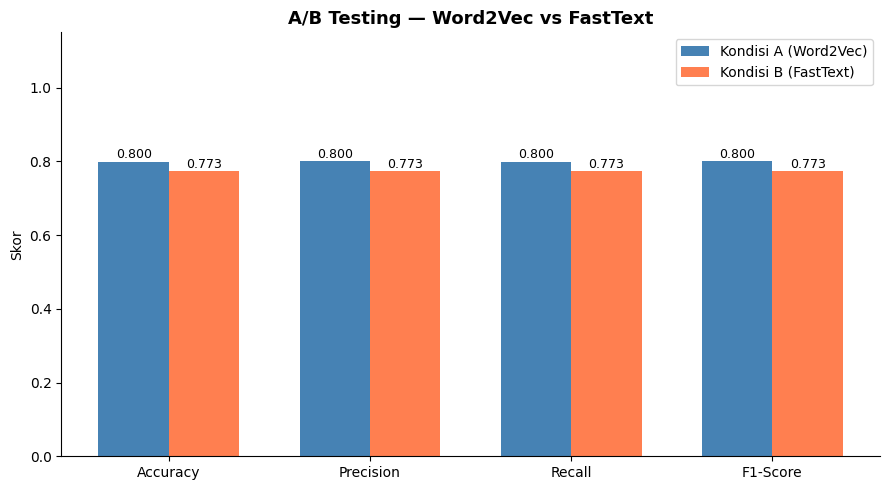

In [84]:
fig, ax = plt.subplots(figsize=(9, 5))

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values_A = [acc_A, prec_A, rec_A, f1_A]
values_B = [acc_B, prec_B, rec_B, f1_B]
x, width = np.arange(len(metrics)), 0.35

ax.bar(x - width/2, values_A, width, label='Kondisi A (Word2Vec)', color='steelblue')
ax.bar(x + width/2, values_B, width, label='Kondisi B (FastText)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_title('A/B Testing — Word2Vec vs FastText', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylabel('Skor')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (va, vb) in enumerate(zip(values_A, values_B)):
    ax.text(i - width/2, va + 0.01, f'{va:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, vb + 0.01, f'{vb:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('nb_images/ab_testing_w2v_vs_ft.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix Kondisi A (Word2Vec)

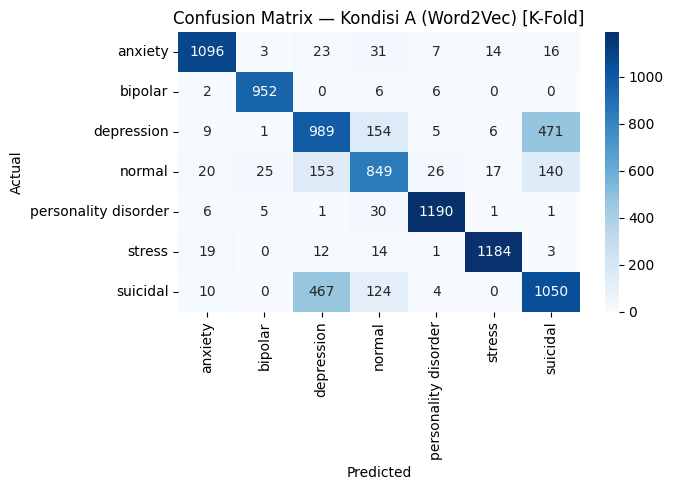

In [85]:
# Confusion Matrix Word2Vec — dari hasil agregasi K-Fold
fig, ax = plt.subplots(figsize=(7, 5))
cm_A = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix — Kondisi A (Word2Vec) [K-Fold]')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('nb_images/cm_word2vec.png', dpi=150, bbox_inches='tight')
plt.show()

##Confusion Matrix Kondisi B (FastText)

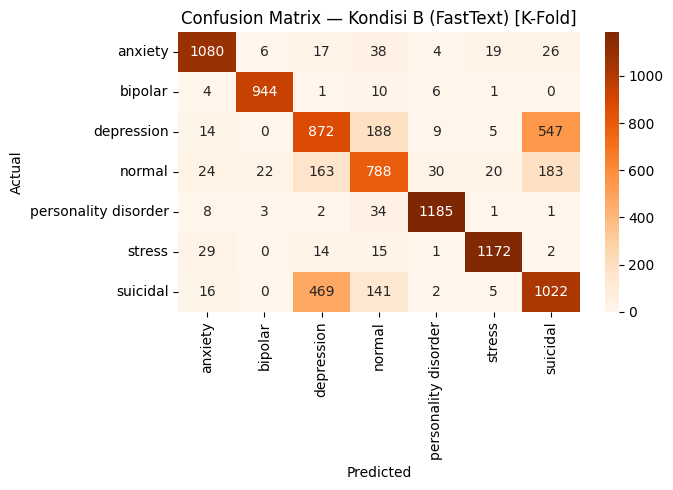

In [86]:
# Confusion Matrix FastText — dari hasil agregasi K-Fold
fig, ax = plt.subplots(figsize=(7, 5))
cm_B = confusion_matrix(all_y_true_B, all_y_pred_B)
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix — Kondisi B (FastText) [K-Fold]')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('nb_images/cm_fasttext.png', dpi=150, bbox_inches='tight')
plt.show()

## Uji Statistik — McNemar Test & Kesimpulan

In [87]:
# McNemar Test menggunakan hasil agregasi K-Fold
correct_A = (np.array(all_y_pred) == np.array(all_y_true))
correct_B = (np.array(all_y_pred_B) == np.array(all_y_true_B))

n11 = np.sum( correct_A &  correct_B)
n10 = np.sum( correct_A & ~correct_B)
n01 = np.sum(~correct_A &  correct_B)
n00 = np.sum(~correct_A & ~correct_B)

result = mcnemar([[n11, n10], [n01, n00]], exact=False, correction=True)

print('HASIL UJI STATISTIK — McNemar Test')
print('=' * 45)
print(f'Statistik : {result.statistic:.4f}')
print(f'P-value   : {result.pvalue:.4f}')
print()
if result.pvalue < 0.05:
    print('Perbedaan SIGNIFIKAN secara statistik (p < 0.05)')
else:
    print('Perbedaan TIDAK signifikan secara statistik (p >= 0.05)')

print()
print('KESIMPULAN')
print('=' * 45)
if f1_B > f1_A:
    selisih = ((f1_B - f1_A) / f1_A) * 100
    print(f'FastText lebih unggul dari Word2Vec')
    print(f'Peningkatan F1-Score : {selisih:.2f}%')
    print('-> Direkomendasikan menggunakan FastText')
elif f1_A > f1_B:
    selisih = ((f1_A - f1_B) / f1_B) * 100
    print(f'Word2Vec lebih unggul dari FastText')
    print(f'Selisih F1-Score : {selisih:.2f}%')
    print('-> Direkomendasikan menggunakan Word2Vec')
else:
    print('Word2Vec dan FastText memiliki performa yang setara')

HASIL UJI STATISTIK — McNemar Test
Statistik : 72.1287
P-value   : 0.0000

Perbedaan SIGNIFIKAN secara statistik (p < 0.05)

KESIMPULAN
Word2Vec lebih unggul dari FastText
Selisih F1-Score : 3.53%
-> Direkomendasikan menggunakan Word2Vec


### Hasil Perbandingan

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ── Hitung metrik global Kondisi A (Word2Vec)
acc_A  = accuracy_score(all_y_true, all_y_pred)
prec_A = precision_score(all_y_true, all_y_pred, average='weighted')
rec_A  = recall_score(all_y_true, all_y_pred, average='weighted')
f1_A   = f1_score(all_y_true, all_y_pred, average='weighted')

# ── Hitung metrik global Kondisi B (FastText)
acc_B  = accuracy_score(all_y_true_B, all_y_pred_B)
prec_B = precision_score(all_y_true_B, all_y_pred_B, average='weighted')
rec_B  = recall_score(all_y_true_B, all_y_pred_B, average='weighted')
f1_B   = f1_score(all_y_true_B, all_y_pred_B, average='weighted')

# ── Tabel perbandingan global
df_global = pd.DataFrame({
    'Metrik'               : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Kondisi A (Word2Vec)' : [acc_A, prec_A, rec_A, f1_A],
    'Kondisi B (FastText)' : [acc_B, prec_B, rec_B, f1_B],
})
df_global['Selisih (B - A)'] = (
    df_global['Kondisi B (FastText)'] - df_global['Kondisi A (Word2Vec)']
)
df_global['Unggul'] = df_global.apply(
    lambda row: 'FastText' if row['Selisih (B - A)'] > 0
    else ('Word2Vec' if row['Selisih (B - A)'] < 0
    else 'Setara'), axis=1
)
df_global = df_global.round(4)

print('PERBANDINGAN GLOBAL — Word2Vec vs FastText (K-Fold)')
print('=' * 65)
print(df_global.to_string(index=False))

PERBANDINGAN GLOBAL — Word2Vec vs FastText (K-Fold)
   Metrik  Kondisi A (Word2Vec)  Kondisi B (FastText)  Selisih (B - A)   Unggul
 Accuracy                0.7995                0.7725          -0.0270 Word2Vec
Precision                0.8002                0.7730          -0.0272 Word2Vec
   Recall                0.7995                0.7725          -0.0270 Word2Vec
 F1-Score                0.7998                0.7725          -0.0273 Word2Vec


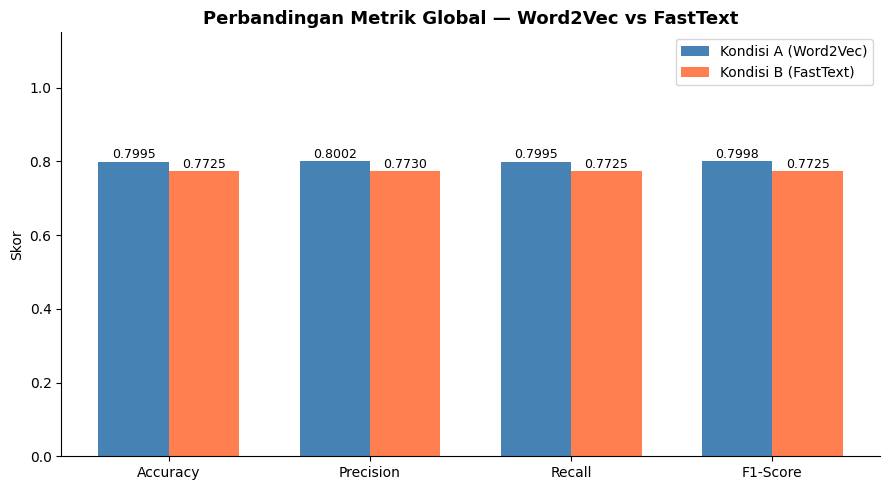

In [89]:
import matplotlib.pyplot as plt
import numpy as np

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values_A = [acc_A, prec_A, rec_A, f1_A]
values_B = [acc_B, prec_B, rec_B, f1_B]
x, width = np.arange(len(metrics)), 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_A = ax.bar(x - width/2, values_A, width, label='Kondisi A (Word2Vec)', color='steelblue')
bars_B = ax.bar(x + width/2, values_B, width, label='Kondisi B (FastText)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Metrik Global — Word2Vec vs FastText', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylabel('Skor')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars_A, values_A):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=9)
for bar, val in zip(bars_B, values_B):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('nb_images/ab_global_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Per Kategori (kelas)

In [90]:
# Analisis Per Kelas — Kondisi A vs B
from sklearn.metrics import classification_report
import pandas as pd

# Ambil report per kelas dalam bentuk dict
report_A = classification_report(all_y_true, all_y_pred,
                                  target_names=le.classes_, output_dict=True)
report_B = classification_report(all_y_true_B, all_y_pred_B,
                                  target_names=le.classes_, output_dict=True)

# Susun tabel per kelas
rows = []
for cls in le.classes_:
    rows.append({
        'Kelas'            : cls,
        'F1 Word2Vec (A)'  : report_A[cls]['f1-score'],
        'F1 FastText (B)'  : report_B[cls]['f1-score'],
        'Selisih (B - A)'  : report_B[cls]['f1-score'] - report_A[cls]['f1-score'],
        'Unggul'           : 'FastText' if report_B[cls]['f1-score'] > report_A[cls]['f1-score']
                             else ('Word2Vec' if report_A[cls]['f1-score'] > report_B[cls]['f1-score']
                             else 'Setara')
    })

df_per_kelas = pd.DataFrame(rows).round(4)

print('PERBANDINGAN F1-SCORE PER KELAS')
print('=' * 60)
print(df_per_kelas.to_string(index=False))

print()
print('RINGKASAN KEUNGGULAN')
print('=' * 60)
ringkasan = df_per_kelas.groupby('Unggul')['Kelas'].apply(list)
for model, kelas_list in ringkasan.items():
    print(f'{model:10s} : {", ".join(kelas_list)}')

PERBANDINGAN F1-SCORE PER KELAS
               Kelas  F1 Word2Vec (A)  F1 FastText (B)  Selisih (B - A)   Unggul
             anxiety           0.9320           0.9133          -0.0187 Word2Vec
             bipolar           0.9754           0.9727          -0.0027 Word2Vec
          depression           0.6030           0.5496          -0.0534 Word2Vec
              normal           0.6965           0.6448          -0.0516 Word2Vec
personality disorder           0.9624           0.9591          -0.0033 Word2Vec
              stress           0.9646           0.9544          -0.0102 Word2Vec
            suicidal           0.6295           0.5949          -0.0346 Word2Vec

RINGKASAN KEUNGGULAN
Word2Vec   : anxiety, bipolar, depression, normal, personality disorder, stress, suicidal


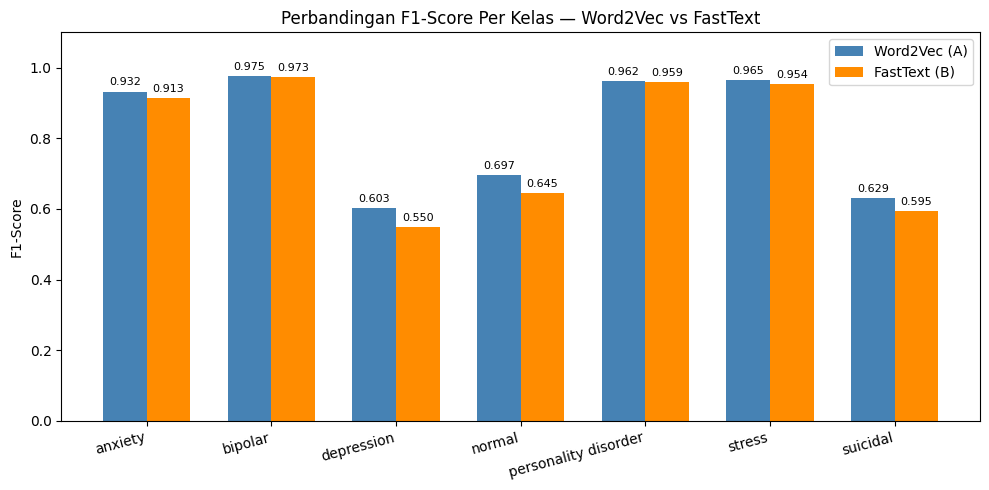

In [91]:
# Bar chart F1 per kelas
x = np.arange(len(le.classes_))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_A = ax.bar(x - width/2, df_per_kelas['F1 Word2Vec (A)'], width,
                label='Word2Vec (A)', color='steelblue')
bars_B = ax.bar(x + width/2, df_per_kelas['F1 FastText (B)'], width,
                label='FastText (B)', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score Per Kelas — Word2Vec vs FastText')
ax.legend()
ax.bar_label(bars_A, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars_B, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('nb_images/f1_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()